
Black Friday complexity simulation.

This script builds an agent-based simulation of consumer behaviour during and after
Black Friday. It creates consumers and products, exposes consumers to products each
week, calculates purchase probabilities, tracks regret, clutter, disposal and waste,
and finally visualises the results.

The code is probabilistic. This means consumers do not follow fixed rules every time.
Instead, each consumer has a probability of buying, using, regretting or discarding
products based on their personal traits and the product characteristics.

REFERENCE AND CALIBRATION NOTES
-------------------------------
The exact parameter weights in this simulation are not estimated from real consumer-level
data. They are theoretically informed modelling assumptions. The purpose is to translate
mechanisms from the literature into a transparent agent-based model.

Key sources used inside the comments:
Adobe. (2025, January 7). 
Adobe: Holiday shopping season drove a record $241.4 billion online and rising 8.7% YoY [Press release]. 
https://news.adobe.com/news/downloads/pdfs/2025/1/adi-pr-full-season-recap-jan-7.pdf

Amos, C., Holmes, G. R., & Keneson, W. C. (2014). 
A meta-analysis of consumer impulse buying. Journal of Retailing and Consumer Services, 21(2), 86–97. 
https://doi.org/10.1016/j.jretconser.2013.11.004

Beikverdi, L., Sipilä, J., & Tarkiainen, A. (2024). Post-purchase effects of impulse buying: A review and research agenda. Journal of Consumer Behaviour, 23(3), 1512–1527. 
https://doi.org/10.1002/cb.2287

Kundu, S., Sharma, B. K., & AlSaleh, D. (2024). 
Consumer product disposition: A systematic literature review and future research agenda. Cleaner and Responsible Consumption, 14, Article 100209. 
https://doi.org/10.1016/j.clrc.2024.100209

Swilley, E., & Goldsmith, R. E. (2013). 
Black Friday and Cyber Monday: Understanding consumer intentions on two major shopping days. Journal of Retailing and Consumer Services, 20(1), 43–50. 
https://doi.org/10.1016/j.jretconser.2012.10.003

Wu, Y., Xin, L., Li, D., Yu, J., & Guo, J. (2021). How does scarcity promotion lead to impulse purchase in the online market? A field experiment. Information & Management, 58(1), Article 103283. https://doi.org/10.1016/j.im.2020.103283
"""

In [1]:
import numpy as np
import pandas as pd
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# numpy is used for random numbers and numerical calculations.
# pandas is used to store simulation results as DataFrames.
# dataclasses are used to keep consumers, products and owned items organised.
# matplotlib is used to create the final dashboard and correlation plots.

# I use a fixed random seed so the simulation gives the same result each time it runs.
# This is useful for presentations because the plots do not randomly change every time.
rng = np.random.default_rng(42)

In [2]:
# ----------------------------
# Visual theme
# ----------------------------

# All dashboard colours are stored here. (These are for the presentation, not for the report, as the font and colors differe between the two formats.)
# This makes it easy to change the visual style without editing every plot separately.
THEME = {
    "background": "#000000",
    "panel": "#111111",
    "panel_light": "#1E1E1E",
    "text": "#FFFFFF",
    "muted_text": "#D9D9D9",
    "lime": "#D8FF7A",
    "lime_soft": "#BFFF5A",
    "grey": "#333333",
    "grid": "#404040",
    "blue": "#7DB7FF",
    "orange": "#FFB86B",
    "red": "#FF6B6B",
    "purple": "#C792EA"
}


def apply_dark_theme(fig, axes=None):
    """Applies the dark dashboard style to a figure and its axes."""

    # Set the full figure background first.
    fig.patch.set_facecolor(THEME["background"])

    if axes is None:
        axes = fig.axes

    for ax in axes:
        ax.set_facecolor(THEME["panel"])
        ax.tick_params(colors=THEME["muted_text"])
        ax.xaxis.label.set_color(THEME["text"])
        ax.yaxis.label.set_color(THEME["text"])
        ax.title.set_color(THEME["text"])

        for spine in ax.spines.values():
            spine.set_color(THEME["grid"])

        ax.grid(True, color=THEME["grid"], alpha=0.25, linewidth=0.7)

        legend = ax.get_legend()
        if legend is not None:
            legend.get_frame().set_facecolor(THEME["panel_light"])
            legend.get_frame().set_edgecolor(THEME["grid"])
            for text in legend.get_texts():
                text.set_color(THEME["text"])

In [3]:
# ----------------------------
# Data classes
# ----------------------------

@dataclass
class Product:
    """Stores the characteristics of one product in the simulated marketplace."""

    product_id: int
    category: str
    base_price: float
    quality: float
    brand_reputation: float
    durability: float
    novelty: float
    inventory: int
    discount: float = 0.0
    scarcity_signal: float = 0.0


@dataclass
class OwnedItem:
    """Stores information about a product after a consumer has bought it."""

    product_id: int
    category: str
    purchase_price: float
    quality: float
    durability: float
    fit_score: float
    weeks_owned: int = 0
    use_history: list = field(default_factory=list)
    current_value: float = 1.0
    discarded: bool = False


@dataclass
class Consumer:
    """Stores one simulated consumer and their behavioural traits."""

    consumer_id: int
    budget: float
    impulse_susceptibility: float
    brand_sensitivity: float
    waste_aversion: float
    social_sensitivity: float
    storage_capacity: int
    regret_memory: float
    baseline_needs: dict
    owned_items: list = field(default_factory=list)

    def clutter_level(self):
        """Calculates how full the consumer's storage is with non-discarded items."""

        # Only items that have not been discarded count as current clutter.
        active_items = sum(1 for item in self.owned_items if not item.discarded)

        # max(..., 1) avoids division by zero if storage_capacity were ever set to 0.
        return active_items / max(self.storage_capacity, 1)



In [ ]:
# ----------------------------
# Initial population
# ----------------------------

def make_consumers(n=400):
    """Creates the simulated population of consumers."""

    # n=400 is a modelling choice rather than a literature estimate.
    # It is large enough to produce aggregate system patterns. In the our report, this should be described
    # as a simulated population, not as a representative sample of real consumers.

    # The category plots help show whether Black Friday affects all product types equally.
    categories = ["electronics", "fashion", "home", "beauty"]
    consumers = []

    for i in range(n):
        # Each consumer has a different basic need for each product category.
        # The normal distribution around 0.5 creates moderate average need, while the
        # standard deviation of 0.2 creates heterogeneity between consumers.
        # This follows Amos et al. (2014), who separate dispositional differences from
        # situational shopping triggers. The exact 0.5 and 0.2 values are modelling
        # assumptions, not directly estimated coefficients.
        baseline_needs = {
            cat: np.clip(rng.normal(0.5, 0.2), 0, 1) for cat in categories
        }

        consumers.append(
            Consumer(
                consumer_id=i,
                # The budget range creates consumer heterogeneity in affordability.
                # It is not meant to match a specific income distribution, but to let
                # price sensitivity matter in the model.
                budget=float(rng.uniform(200, 2500)),

                # beta(2, 2) creates values mostly around the middle, with some low
                # and high consumers. This is useful for traits such as impulsiveness,
                # brand sensitivity, waste aversion and social sensitivity because
                # Amos et al. (2014) show that impulse buying depends on individual
                # traits as well as the shopping situation.
                impulse_susceptibility=float(rng.beta(2, 2)),
                brand_sensitivity=float(rng.beta(2, 2)),
                waste_aversion=float(rng.beta(2, 2)),
                social_sensitivity=float(rng.beta(2, 2)),

                # Storage capacity creates a simple material constraint. This supports
                # the disposal mechanism, because Kundu et al. (2024) argue that product
                # disposition depends on product use, perceived value and context.
                storage_capacity=int(rng.integers(10, 40)),

                # beta(2, 5) gives most consumers low initial regret memory, while still
                # allowing some consumers to start with higher regret. This supports the
                # idea from post-purchase impulse buying literature that regret develops
                # through consumption experience rather than being fixed at the start.
                regret_memory=float(rng.beta(2, 5)),
                baseline_needs=baseline_needs
            )
        )

    return consumers


def make_products():
    """Creates the product catalogue used in the simulation."""

    categories = ["electronics", "fashion", "home", "beauty"]
    products = []
    pid = 0

    for cat in categories:
        for _ in range(40):
            # Every category gets 40 products, but their price ranges differ.
            # Electronics are usually more expensive, while beauty products are cheaper.
            # These prices are stylised, not scraped from real retailers. The important
            # theoretical point is that different product categories create different
            # affordability constraints and impulse opportunities.
            base_price = {
                "electronics": rng.uniform(80, 800),
                "fashion": rng.uniform(15, 180),
                "home": rng.uniform(20, 250),
                "beauty": rng.uniform(10, 120)
            }[cat]

            # Durability is measured in weeks.
            # For example, electronics and home products are expected to last longer.
            # Kundu et al. (2024) show that product disposition research must consider
            # the product life after purchase, including use and perceived value.
            # The exact durability ranges are stylised assumptions that let some categories
            # become disposable faster than others.
            durability = {
                "electronics": rng.uniform(52, 260),
                "fashion": rng.uniform(20, 100),
                "home": rng.uniform(52, 208),
                "beauty": rng.uniform(8, 52)
            }[cat]

            products.append(
                Product(
                    product_id=pid,
                    category=cat,
                    base_price=float(base_price),
                    quality=float(rng.uniform(0.2, 0.95)),
                    brand_reputation=float(rng.uniform(0.2, 0.95)),
                    durability=float(durability),
                    novelty=float(rng.uniform(0.2, 1.0)),
                    inventory=int(rng.integers(30, 300))
                )
            )

            pid += 1

    return products



In [5]:
# ----------------------------
# Behavioural functions
# ----------------------------

def sigmoid(x):
    """Converts a raw score into a probability between 0 and 1."""

    return 1 / (1 + np.exp(-x))


def apply_black_friday(products, week, bf_week=0, bf_duration=1, post_bf_duration=3):
    """Updates discounts and scarcity signals depending on the Black Friday period."""

    # This measures where the current week is relative to Black Friday in a yearly cycle.
    distance_from_bf = (week - bf_week) % 52

    for p in products:
        if distance_from_bf < bf_duration:
            # During Black Friday, discounts and scarcity signals are strongest.
            # Different categories get different average discount levels.
            #
            # The discount values are calibrated loosely around Adobe Analytics holiday
            # discount data. Adobe reported 2024 peak online discounts of about 30.1%
            # for electronics, 23.2% for apparel and 19% for furniture/home goods.
            # The model therefore uses roughly 32% for electronics, 27% for fashion,
            # 22% for home and 24% for beauty. Beauty is an approximation because the
            # cited public category is not exactly the same as this model's beauty category.
            #
            # These values should be interpreted as theoretically plausible Black Friday
            # shock values, not exact empirical estimates.
            category_discount_mean = {
                "electronics": 0.32,
                "fashion": 0.27,
                "home": 0.22,
                "beauty": 0.24
            }[p.category]

            # Discounts are random around the category mean so products are not identical.
            # The 12-45% range represents a strong promotional event.
            p.discount = float(np.clip(rng.normal(category_discount_mean, 0.07), 0.12, 0.45))

            # Scarcity is high during Black Friday to represent "limited time" and
            # "limited quantity" promotional cues. Wu et al. (2021) show that both
            # limited-time scarcity and limited-quantity scarcity increase perceived
            # arousal, which then increases impulse purchase.
            p.scarcity_signal = float(np.clip(rng.normal(0.80, 0.12), 0.35, 1.00))

        elif distance_from_bf < bf_duration + post_bf_duration:
            # After Black Friday, discounts are still present but weaker.
            # This represents the common extension of promotions into Cyber Week and
            # post-Black-Friday campaigns. The discount is therefore lower than the
            # main Black Friday shock, but still above normal weeks.
            p.discount = float(np.clip(rng.normal(0.16, 0.05), 0.05, 0.30))
            p.scarcity_signal = float(np.clip(rng.normal(0.35, 0.10), 0.10, 0.60))

        else:
            # During normal weeks, discounts and scarcity signals are low.
            # This baseline creates contrast with Black Friday. Without a low baseline,
            # the model would not clearly separate event-driven consumption from normal
            # shopping behaviour.
            p.discount = float(np.clip(rng.normal(0.06, 0.03), 0.00, 0.15))
            p.scarcity_signal = float(np.clip(rng.normal(0.08, 0.04), 0.00, 0.20))


def social_hype_schedule(week, bf_week=0):
    """Returns how much social pressure or hype exists in a given week."""

    distance_from_bf = (week - bf_week) % 52

    # Social hype is highest during Black Friday itself, then fades.
    # Swilley and Goldsmith (2013) describe Black Friday as more hedonic and socially
    # enjoyable than purely utilitarian online shopping. Amos et al. (2014) also identify
    # social influence as a relevant impulse-buying factor. The 0.90, 0.55, 0.30 and 0.10
    # values are therefore theoretical intensity levels rather than measured statistics.
    if distance_from_bf == 0:
        return 0.90
    elif distance_from_bf == 1:
        return 0.55
    elif distance_from_bf <= 3:
        return 0.30
    else:
        return 0.10


def shopping_exposure(week, bf_week=0):
    """Returns how many products each consumer sees in a given week."""

    distance_from_bf = (week - bf_week) % 52

    # Exposure increases sharply during Black Friday because consumers face more
    # promotions, product recommendations, ads and sale cues. This follows the idea
    # that situational triggers matter for impulse buying (Amos et al., 2014).
    # The values are stylised: normal weeks show 2 products, Black Friday shows 18.
    if distance_from_bf == 0:
        return 18
    elif distance_from_bf == 1:
        return 10
    elif distance_from_bf <= 3:
        return 5
    else:
        return 2


def product_fit(consumer, product):
    """Calculates how well a product fits a specific consumer."""

    # Fit mostly depends on the consumer's baseline need for the category.
    # A smaller random part is added to represent personal taste and randomness.
    # The 65/35 split makes need more important than random attraction, but still
    # allows impulse and novelty to matter. This connects to Kundu et al. (2024),
    # because product use and perceived value later influence disposition.
    base_need = consumer.baseline_needs[product.category]
    random_fit = rng.uniform(0.0, 1.0)
    return 0.65 * base_need + 0.35 * random_fit


def duplicate_penalty(consumer, category):
    """Penalises buying more products from a category the consumer already owns."""

    duplicates = sum(
        1 for item in consumer.owned_items
        if (not item.discarded) and item.category == category
    )

    # The penalty grows with each duplicate item, but it is capped at 0.75.
    # This models diminishing need: owning more similar products should make another
    # purchase less attractive. The exact 0.15 step is a modelling assumption.
    return min(duplicates * 0.15, 0.75)


def buy_probability(consumer, product, social_hype):
    """Calculates whether a consumer is likely to buy a product."""

    # First, calculate how relevant the product is and what it costs after discount.
    fit = product_fit(consumer, product)
    final_price = product.base_price * (1 - product.discount)
    affordability = 1 if consumer.budget >= final_price else 0

    # A consumer cannot buy the product if they cannot afford it or if it is sold out.
    if affordability == 0 or product.inventory <= 0:
        return 0.0, fit, final_price, 0.0

    clutter = consumer.clutter_level()
    dup_pen = duplicate_penalty(consumer, product.category)

    # This score combines product attraction, consumer traits and negative pressures.
    # Positive terms increase buying probability, while clutter, regret and high price reduce it.
    #
    # The exact weights are not empirical regression coefficients. They are theory-based
    # assumptions chosen to make the model behaviour interpretable.
    #
    # fit gets a strong positive weight because need and product relevance should matter.
    # discount and scarcity also get strong weights because Black Friday promotions are
    # central to the research question. Adobe discount data supports large Black Friday
    # markdowns, while Wu et al. (2021) support the link from scarcity cues to arousal
    # and impulse purchase.
    #
    # impulse_susceptibility represents the dispositional impulse buying trait discussed
    # by Amos et al. (2014). social_sensitivity * social_hype represents the interaction
    # between a consumer trait and a shopping situation, which Amos et al. (2014) identify
    # as especially important. brand_sensitivity is included with a smaller weight because
    # brand reputation matters, but the model focuses more on discount/scarcity.
    #
    # clutter, regret_memory, duplicate_penalty and relative price reduce buying probability.
    # These negative terms represent self-regulation, past regret and practical constraints.
    score = (
        2.4 * fit
        + 2.6 * product.discount
        + 2.1 * product.scarcity_signal
        + 0.6 * product.novelty
        + 1.5 * consumer.impulse_susceptibility
        + 1.1 * consumer.social_sensitivity * social_hype
        + 0.7 * consumer.brand_sensitivity * product.brand_reputation
        - 2.0 * clutter
        - 1.6 * consumer.regret_memory
        - 1.1 * dup_pen
        - 0.6 * (final_price / max(consumer.budget, 1))
    )

    # The score is shifted and then passed through the sigmoid function.
    # This turns it into a probability between 0 and 1.
    # The -4.8 calibration keeps normal-week purchasing relatively low, so that
    # Black Friday discounts, scarcity and exposure can create a visible spike.
    # This is a calibration choice, not a number taken from a specific paper.
    p_buy = float(sigmoid(score - 4.8))

    # This separate score estimates whether a purchase is impulsive.
    # It is not the buying probability itself, but a label used after a purchase happens.
    #
    # Amos et al. (2014) report that impulse purchases can make up around 40-80% of
    # purchases depending on product category. This model therefore lets impulse purchases
    # become common during Black Friday, but not automatic.
    #
    # The strongest part of the impulse score is the consumer's own impulse susceptibility.
    # Discount, scarcity and hype are also important because impulse buying is driven by
    # the interaction between dispositional and situational factors. Low fit is included
    # because purchases with weaker need-fit are more likely to be instant-gratification
    # purchases rather than planned purchases.
    impulse_score = np.clip(
        0.40 * consumer.impulse_susceptibility
        + 0.25 * product.discount
        + 0.20 * product.scarcity_signal
        + 0.15 * social_hype
        + 0.15 * (1 - fit),
        0,
        1
    )

    return p_buy, fit, final_price, float(impulse_score)


def buy_product(consumer, product, fit, price):
    """Updates the consumer and product after a purchase has happened."""

    # The consumer spends money and the product loses one unit of inventory.
    consumer.budget -= price
    product.inventory -= 1

    consumer.owned_items.append(
        OwnedItem(
            product_id=product.product_id,
            category=product.category,
            purchase_price=price,
            quality=product.quality,
            durability=product.durability,
            fit_score=fit
        )
    )


def update_use_and_disposal(consumer):
    """Updates item use, regret and disposal for one consumer during one week."""

    discarded_this_week = 0
    regret_events = 0

    for item in consumer.owned_items:
        if item.discarded:
            continue

        # Every active item becomes one week older.
        item.weeks_owned += 1

        # Novelty declines over time, meaning products become less exciting as they age.
        # The exponential decay represents the fading of hedonic excitement after purchase.
        # This is connected to post-purchase impulse buying research, where impulse purchases
        # can produce both satisfaction and later regret or cognitive dissonance.
        novelty_decay = np.exp(-0.06 * item.weeks_owned)
        clutter = consumer.clutter_level()

        # The chance of using an item depends mostly on fit and quality.
        # Clutter lowers use because too many items compete for attention.
        # This follows the product disposition logic from Kundu et al. (2024):
        # whether a product is retained or discarded depends partly on use and
        # perceived value after purchase.
        use_prob = np.clip(
            0.60 * item.fit_score
            + 0.20 * item.quality
            + 0.15 * novelty_decay
            - 0.20 * clutter,
            0.02,
            0.95
        )

        used = rng.random() < use_prob
        item.use_history.append(int(used))

        # Recent use looks at the last 8 weeks, which makes disposal depend on recent behaviour.
        # The 8-week window is a modelling assumption. It gives the item enough time to be
        # used after purchase while still allowing delayed post-Black-Friday disposal to appear.
        recent_use = np.mean(item.use_history[-8:]) if item.use_history else 0

        # The item's value slowly decreases over time.
        # Unused items lose a bit more value than used items.
        item.current_value = max(
            0.0,
            item.current_value - (1 / max(item.durability, 1)) - (0.01 if used else 0.02)
        )

        # Regret is more likely when the item is a poor fit or has not been used recently.
        # Waste aversion reduces regret because these consumers are more reluctant to see items as mistakes.
        #
        # Post-purchase impulse buying literature identifies regret, guilt and cognitive
        # dissonance as common negative outcomes of impulse buying. This supports the
        # use of fit, recent use and clutter as regret triggers.
        regret_prob = np.clip(
            0.45 * (1 - item.fit_score)
            + 0.20 * (1 - recent_use)
            + 0.10 * clutter
            - 0.25 * consumer.waste_aversion,
            0.0,
            0.85
        )

        regret = rng.random() < regret_prob

        if regret:
            regret_events += 1

            # Regret memory increases slowly so one bad purchase does not fully define
            # future behaviour. The 0.025 increase is a behavioural memory calibration,
            # used to create a feedback loop from post-purchase regret to later restraint.
            consumer.regret_memory = min(1.0, consumer.regret_memory + 0.025)

        # Disposal is more likely when the item is not used, is old, or contributes to clutter.
        # Waste aversion reduces the probability of discarding.
        #
        # Kundu et al. (2024) identify use, perceived value, environmental concern and
        # social/contextual factors as important for product disposition. This formula
        # translates those mechanisms into a simplified discard probability.
        discard_prob = np.clip(
            0.20 * (1 - recent_use)
            + 0.12 * (item.weeks_owned / max(item.durability, 1))
            + 0.10 * clutter
            + 0.12 * regret_prob
            - 0.30 * consumer.waste_aversion,
            0.0,
            0.65
        )

        # The item must be owned for more than 8 weeks before it can be discarded.
        # This creates a delay between Black Friday purchases and later waste, which fits
        # the paper's argument that impulse consumption can have post-purchase effects.
        if rng.random() < discard_prob and item.weeks_owned > 8:
            item.discarded = True
            discarded_this_week += 1

    # Regret memory fades slightly each week, so past regret does not affect decisions forever.
    # The 0.008 decay creates a slow feedback loop rather than permanent regret.
    consumer.regret_memory = max(0.0, consumer.regret_memory - 0.008)

    return discarded_this_week, regret_events

In [6]:
# ----------------------------
# Simulation
# ----------------------------

def run_simulation(
    n_consumers=400,
    weeks=52,
    bf_week=0
):
    """Runs the full weekly simulation and returns the results."""

    # Create the agents and the marketplace before the weekly loop starts.
    consumers = make_consumers(n_consumers)
    products = make_products()

    records = []
    categories = ["electronics", "fashion", "home", "beauty"]

    for week in range(weeks):
        # calendar_week keeps the Black Friday logic inside a 52-week yearly cycle.
        calendar_week = week % 52

        # Update the market conditions for this week.
        # Black Friday affects discounts, scarcity, hype and shopping exposure.
        apply_black_friday(products, calendar_week, bf_week=bf_week)
        social_hype = social_hype_schedule(calendar_week, bf_week=bf_week)
        n_visible_products = shopping_exposure(calendar_week, bf_week=bf_week)

        purchases = 0
        impulse_purchases = 0
        total_spent = 0.0
        discarded = 0
        regrets = 0

        category_purchases = {cat: 0 for cat in categories}
        category_discards = {cat: 0 for cat in categories}

        for consumer in consumers:
            # Each consumer only sees a sample of products each week.
            # During Black Friday, this sample is larger because exposure is higher.
            visible_products = rng.choice(products, size=n_visible_products, replace=False)

            for product in visible_products:
                p_buy, fit, price, impulse_score = buy_probability(consumer, product, social_hype)

                # The actual purchase is random, but weighted by the calculated probability.
                if rng.random() < p_buy:
                    buy_product(consumer, product, fit, price)
                    purchases += 1
                    total_spent += price
                    category_purchases[product.category] += 1

                    if impulse_score > 0.55:
                        impulse_purchases += 1

            # After shopping, the consumer updates use, regret and possible disposal.
            d, r = update_use_and_disposal(consumer)
            discarded += d
            regrets += r

        for cat in categories:
            category_discards[cat] = sum(
                1
                for c in consumers
                for item in c.owned_items
                if item.discarded and item.category == cat
            )

        # These system-level totals summarise the whole simulated population.
        active_items = sum(
            1 for c in consumers for item in c.owned_items if not item.discarded
        )

        waste_stock = sum(
            1 for c in consumers for item in c.owned_items if item.discarded
        )

        avg_budget = np.mean([c.budget for c in consumers])
        avg_regret_memory = np.mean([c.regret_memory for c in consumers])
        avg_clutter = np.mean([c.clutter_level() for c in consumers])

        # Store all important weekly outcomes in one dictionary.
        # This later becomes one row in the results DataFrame.
        record = {
            "week": week,
            "black_friday_week": int(calendar_week == bf_week),
            "purchases": purchases,
            "impulse_purchases": impulse_purchases,
            "impulse_share": impulse_purchases / purchases if purchases > 0 else 0,
            "total_spent": total_spent,
            "discarded_this_week": discarded,
            "regret_events": regrets,
            "active_items": active_items,
            "waste_stock": waste_stock,
            "avg_budget": avg_budget,
            "avg_regret_memory": avg_regret_memory,
            "avg_clutter": avg_clutter
        }

        for cat in categories:
            record[f"purchases_{cat}"] = category_purchases[cat]
            record[f"discarded_{cat}"] = category_discards[cat]

        records.append(record)

    return pd.DataFrame(records), consumers, products


In [7]:
# ----------------------------
# Summary and correlation data
# ----------------------------

def consumer_summary(consumers):
    """Creates one summary row per consumer after the simulation has finished."""

    rows = []

    for consumer in consumers:
        active_items = [item for item in consumer.owned_items if not item.discarded]
        discarded_items = [item for item in consumer.owned_items if item.discarded]
        total_items = len(consumer.owned_items)

        avg_fit = np.mean([item.fit_score for item in consumer.owned_items]) if total_items > 0 else 0
        avg_weeks = np.mean([item.weeks_owned for item in consumer.owned_items]) if total_items > 0 else 0

        rows.append({
            "consumer_id": consumer.consumer_id,
            "budget_left": consumer.budget,
            "impulse_susceptibility": consumer.impulse_susceptibility,
            "brand_sensitivity": consumer.brand_sensitivity,
            "waste_aversion": consumer.waste_aversion,
            "social_sensitivity": consumer.social_sensitivity,
            "regret_memory": consumer.regret_memory,
            "clutter_level": consumer.clutter_level(),
            "total_items_bought": total_items,
            "active_items": len(active_items),
            "discarded_items": len(discarded_items),
            "discard_rate": len(discarded_items) / total_items if total_items > 0 else 0,
            "avg_fit_score": avg_fit,
            "avg_weeks_owned": avg_weeks
        })

    return pd.DataFrame(rows)


def make_correlation_tables(results, consumers):
    """Builds consumer-level and weekly correlation tables."""

    consumer_df = consumer_summary(consumers)

    consumer_variables = [
        "impulse_susceptibility",
        "brand_sensitivity",
        "waste_aversion",
        "social_sensitivity",
        "regret_memory",
        "clutter_level",
        "total_items_bought",
        "active_items",
        "discarded_items",
        "discard_rate",
        "avg_fit_score"
    ]

    weekly_variables = [
        "purchases",
        "impulse_purchases",
        "impulse_share",
        "total_spent",
        "discarded_this_week",
        "regret_events",
        "active_items",
        "waste_stock",
        "avg_budget",
        "avg_regret_memory",
        "avg_clutter"
    ]

    consumer_corr = consumer_df[consumer_variables].corr()
    weekly_corr = results[weekly_variables].corr()

    return consumer_df, consumer_corr, weekly_corr


def print_key_correlations(consumer_corr, weekly_corr):
    """Prints selected correlations that are useful for interpreting the simulation."""

    print("\nConsumer-level correlations with discard rate")
    print(consumer_corr["discard_rate"].sort_values(ascending=False))

    print("\nConsumer-level correlations with total items bought")
    print(consumer_corr["total_items_bought"].sort_values(ascending=False))

    print("\nWeekly correlations with purchases")
    print(weekly_corr["purchases"].sort_values(ascending=False))

    print("\nWeekly correlations with waste stock")
    print(weekly_corr["waste_stock"].sort_values(ascending=False))


In [8]:
# ----------------------------
# Visualisation functions
# ----------------------------

def add_black_friday_bands(ax, results):
    """Adds highlighted bands to plots to show where Black Friday happens."""

    bf_weeks = results.loc[results["black_friday_week"] == 1, "week"].tolist()

    for w in bf_weeks:
        ax.axvspan(w - 0.5, w + 0.5, color=THEME["lime"], alpha=0.18)


def visualize_simulation(results, consumers):
    """Creates the main multi-panel dashboard for the simulation."""

    consumer_df = consumer_summary(consumers)

    # GridSpec gives more control over the dashboard layout than a basic subplot grid.
    fig = plt.figure(figsize=(22, 13), facecolor=THEME["background"])
    gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.22)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[1, 0])
    ax5 = fig.add_subplot(gs[1, 1])
    ax6 = fig.add_subplot(gs[1, 2])
    ax7 = fig.add_subplot(gs[2, :2])
    ax8 = fig.add_subplot(gs[2, 2])

    axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]

    # Plot 1 shows the overall purchase spike and how much of it is impulsive.
    ax1.plot(results["week"], results["purchases"], linewidth=2.5, color=THEME["lime"])
    ax1.plot(results["week"], results["impulse_purchases"], linewidth=2.5, color=THEME["orange"])
    add_black_friday_bands(ax1, results)
    ax1.set_title("Weekly Purchases and Impulse Purchases")
    ax1.set_xlabel("Week")
    ax1.set_ylabel("Count")
    ax1.legend(["Purchases", "Impulse purchases"])

    # Plot 2 compares accumulated waste with items still actively owned.
    ax2.plot(results["week"], results["waste_stock"], linewidth=2.5, color=THEME["red"])
    ax2.plot(results["week"], results["active_items"], linewidth=2.5, color=THEME["lime"])
    add_black_friday_bands(ax2, results)
    ax2.set_title("Accumulated Waste Stock vs Active Items")
    ax2.set_xlabel("Week")
    ax2.set_ylabel("Items")
    ax2.legend(["Waste stock", "Active items"])

    # Plot 3 links impulsive buying with average regret memory over time.
    ax3.plot(results["week"], results["impulse_share"], linewidth=2.5, color=THEME["orange"])
    ax3.plot(results["week"], results["avg_regret_memory"], linewidth=2.5, color=THEME["purple"])
    add_black_friday_bands(ax3, results)
    ax3.set_title("Impulse Share and Average Regret Memory")
    ax3.set_xlabel("Week")
    ax3.set_ylabel("Level")
    ax3.legend(["Impulse share", "Avg regret memory"])

    categories = ["electronics", "fashion", "home", "beauty"]
    purchase_matrix = np.vstack([results[f"purchases_{cat}"].values for cat in categories])

    ax4.stackplot(
        results["week"],
        purchase_matrix,
        labels=categories,
        colors=[THEME["lime"], THEME["orange"], THEME["blue"], THEME["purple"]],
        alpha=0.85
    )
    add_black_friday_bands(ax4, results)
    ax4.set_title("Purchases by Category Over Time")
    ax4.set_xlabel("Week")
    ax4.set_ylabel("Purchases")
    ax4.legend(loc="upper right")

    # Plot 5 shows weekly disposal, which often appears after purchases rather than immediately.
    ax5.plot(results["week"], results["discarded_this_week"], linewidth=2.5, color=THEME["red"])
    add_black_friday_bands(ax5, results)
    ax5.set_title("Items Discarded Per Week")
    ax5.set_xlabel("Week")
    ax5.set_ylabel("Discarded items")

    # Plot 6 maps consumers by impulsiveness and discard rate.
    # The dot size shows how many items they bought, and the colour shows waste aversion.
    scatter = ax6.scatter(
        consumer_df["impulse_susceptibility"],
        consumer_df["discard_rate"],
        s=np.maximum(consumer_df["total_items_bought"], 1) * 8,
        c=consumer_df["waste_aversion"],
        cmap="summer",
        alpha=0.8,
        edgecolors=THEME["background"],
        linewidths=0.3
    )

    ax6.set_title("Consumer Map")
    ax6.set_xlabel("Impulse susceptibility")
    ax6.set_ylabel("Discard rate")
    cbar = plt.colorbar(scatter, ax=ax6)
    cbar.set_label("Waste aversion", color=THEME["text"])
    cbar.ax.yaxis.set_tick_params(color=THEME["muted_text"])
    plt.setp(cbar.ax.get_yticklabels(), color=THEME["muted_text"])

    # Plot 7 uses two y-axes to compare budget depletion and clutter build-up.
    ax7.plot(results["week"], results["avg_budget"], linewidth=2.5, color=THEME["lime"])
    ax7_twin = ax7.twinx()
    ax7_twin.plot(results["week"], results["avg_clutter"], linewidth=2.5, color=THEME["orange"])

    add_black_friday_bands(ax7, results)

    ax7.set_title("Budget Depletion and Clutter Build-Up")
    ax7.set_xlabel("Week")
    ax7.set_ylabel("Average remaining budget")
    ax7_twin.set_ylabel("Average clutter")
    ax7.legend(["Avg budget left"], loc="upper left")
    ax7_twin.legend(["Avg clutter"], loc="upper right")

    ax7_twin.set_facecolor(THEME["panel"])
    ax7_twin.tick_params(colors=THEME["muted_text"])
    ax7_twin.yaxis.label.set_color(THEME["text"])
    for spine in ax7_twin.spines.values():
        spine.set_color(THEME["grid"])

    bins = np.linspace(0, 1, 20)

    # Plot 8 shows whether most consumers discard little or whether discard behaviour is widespread.
    ax8.hist(
        consumer_df["discard_rate"],
        bins=bins,
        color=THEME["lime"],
        alpha=0.85,
        edgecolor=THEME["background"]
    )
    ax8.set_title("Distribution of Consumer Discard Rates")
    ax8.set_xlabel("Discard rate")
    ax8.set_ylabel("Number of consumers")

    apply_dark_theme(fig, axes)

    fig.suptitle(
        "Black Friday Complexity Simulation Dashboard",
        fontsize=22,
        y=0.98,
        color=THEME["text"]
    )

    plt.show()


def plot_black_friday_start_window(results, window=12):
    """Zooms in on the first weeks after Black Friday."""

    temp = results.iloc[:window + 1]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), facecolor=THEME["background"])

    axes[0].plot(temp["week"], temp["purchases"], linewidth=2.5, color=THEME["lime"])
    axes[0].plot(temp["week"], temp["impulse_purchases"], linewidth=2.5, color=THEME["orange"])
    axes[0].axvline(0, linestyle="--", linewidth=2, color=THEME["lime"])
    axes[0].set_title("Purchases After Black Friday Start")
    axes[0].set_xlabel("Week")
    axes[0].set_ylabel("Purchases")
    axes[0].legend(["Purchases", "Impulse purchases"])

    axes[1].plot(temp["week"], temp["impulse_share"], linewidth=2.5, color=THEME["orange"])
    axes[1].axvline(0, linestyle="--", linewidth=2, color=THEME["lime"])
    axes[1].set_title("Impulse Share After Black Friday")
    axes[1].set_xlabel("Week")
    axes[1].set_ylabel("Impulse share")

    axes[2].plot(temp["week"], temp["discarded_this_week"], linewidth=2.5, color=THEME["red"])
    axes[2].axvline(0, linestyle="--", linewidth=2, color=THEME["lime"])
    axes[2].set_title("Delayed Discarding After Black Friday")
    axes[2].set_xlabel("Week")
    axes[2].set_ylabel("Discarded items")

    apply_dark_theme(fig, axes)

    plt.tight_layout()
    plt.show()


def plot_correlation_matrix(corr_matrix, title):
    """Plots a labelled correlation matrix with values written inside each cell."""

    fig, ax = plt.subplots(figsize=(11, 9), facecolor=THEME["background"])

    ax.set_facecolor(THEME["panel"])

    # vmin and vmax force all correlation plots to use the same -1 to 1 scale.
    image = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="summer")
    cbar = plt.colorbar(image, ax=ax)
    cbar.ax.yaxis.set_tick_params(color=THEME["muted_text"])
    plt.setp(cbar.ax.get_yticklabels(), color=THEME["muted_text"])

    ax.set_xticks(np.arange(len(corr_matrix.columns)))
    ax.set_yticks(np.arange(len(corr_matrix.index)))

    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right", color=THEME["text"])
    ax.set_yticklabels(corr_matrix.index, color=THEME["text"])

    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):
            value = corr_matrix.iloc[i, j]
            text_color = THEME["background"] if abs(value) > 0.55 else THEME["text"]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8, color=text_color)

    ax.set_title(title, color=THEME["text"], fontsize=16)

    for spine in ax.spines.values():
        spine.set_color(THEME["grid"])

    plt.tight_layout()
    plt.show()


def plot_key_correlation_bars(consumer_corr, weekly_corr):
    """Plots the most readable correlation summaries as horizontal bar charts."""

    discard_corr = consumer_corr["discard_rate"].drop("discard_rate").sort_values()
    purchase_corr = weekly_corr["purchases"].drop("purchases").sort_values()

    fig, ax = plt.subplots(figsize=(10, 5), facecolor=THEME["background"])
    ax.barh(discard_corr.index, discard_corr.values, color=THEME["lime"])
    ax.axvline(0, linewidth=1.2, color=THEME["text"])
    ax.set_title("Consumer-Level Correlations with Discard Rate")
    ax.set_xlabel("Correlation")
    apply_dark_theme(fig, [ax])
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5), facecolor=THEME["background"])
    ax.barh(purchase_corr.index, purchase_corr.values, color=THEME["lime"])
    ax.axvline(0, linewidth=1.2, color=THEME["text"])
    ax.set_title("Weekly Correlations with Purchases")
    ax.set_xlabel("Correlation")
    apply_dark_theme(fig, [ax])
    plt.tight_layout()
    plt.show()


In [9]:
# ----------------------------
# Model calibration notes
# ----------------------------

def print_model_calibration_notes():
    """Prints the theoretical basis for the most important model values."""

    notes = {
        "Black Friday discount range": (
            "The model uses stronger discounts during Black Friday. This is loosely "
            "calibrated against Adobe Analytics holiday data, where 2024 peak online "
            "discounts were about 30.1% for electronics, 23.2% for apparel and 19% "
            "for furniture/home goods. The simulation therefore uses category means "
            "around 22-32% during Black Friday."
        ),
        "Impulse buying prevalence": (
            "Amos, Holmes and Keneson (2014) report that impulse buying can account "
            "for roughly 40-80% of purchases depending on category. The model uses "
            "this as a plausibility range rather than forcing the result."
        ),
        "Scarcity signal": (
            "Song et al. (2021) show that limited-time and limited-quantity scarcity "
            "increase perceived arousal, which then increases impulse purchase. "
            "This supports the high scarcity_signal during Black Friday."
        ),
        "Post-purchase regret": (
            "The post-purchase impulse buying literature identifies regret, guilt "
            "and cognitive dissonance as important outcomes. The model therefore "
            "allows poor fit, low use and clutter to generate regret events."
        ),
        "Disposal and waste": (
            "Kundu et al. (2024) show that product disposition depends "
            "on product use, perceived value, environmental concern and social/contextual "
            "factors. The model therefore connects use_history, fit_score, current_value, "
            "waste_aversion and discard_prob."
        ),
        "Important warning": (
            "The model parameters are not causal estimates from real-world data. They "
            "are transparent, theory-informed assumptions used to explore a complex "
            "system mechanism."
        )
    }

    print("\nModel calibration notes")
    for key, value in notes.items():
        print(f"\n{key}")
        print(value)



Model calibration notes

Black Friday discount range
The model uses stronger discounts during Black Friday. This is loosely calibrated against Adobe Analytics holiday data, where 2024 peak online discounts were about 30.1% for electronics, 23.2% for apparel and 19% for furniture/home goods. The simulation therefore uses category means around 22-32% during Black Friday.

Impulse buying prevalence
Amos, Holmes and Keneson (2014) report that impulse buying can account for roughly 40-80% of purchases depending on category. The model uses this as a plausibility range rather than forcing the result.

Scarcity signal
Song et al. (2021) show that limited-time and limited-quantity scarcity increase perceived arousal, which then increases impulse purchase. This supports the high scarcity_signal during Black Friday.

Post-purchase regret
The post-purchase impulse buying literature identifies regret, guilt and cognitive dissonance as important outcomes. The model therefore allows poor fit, low us

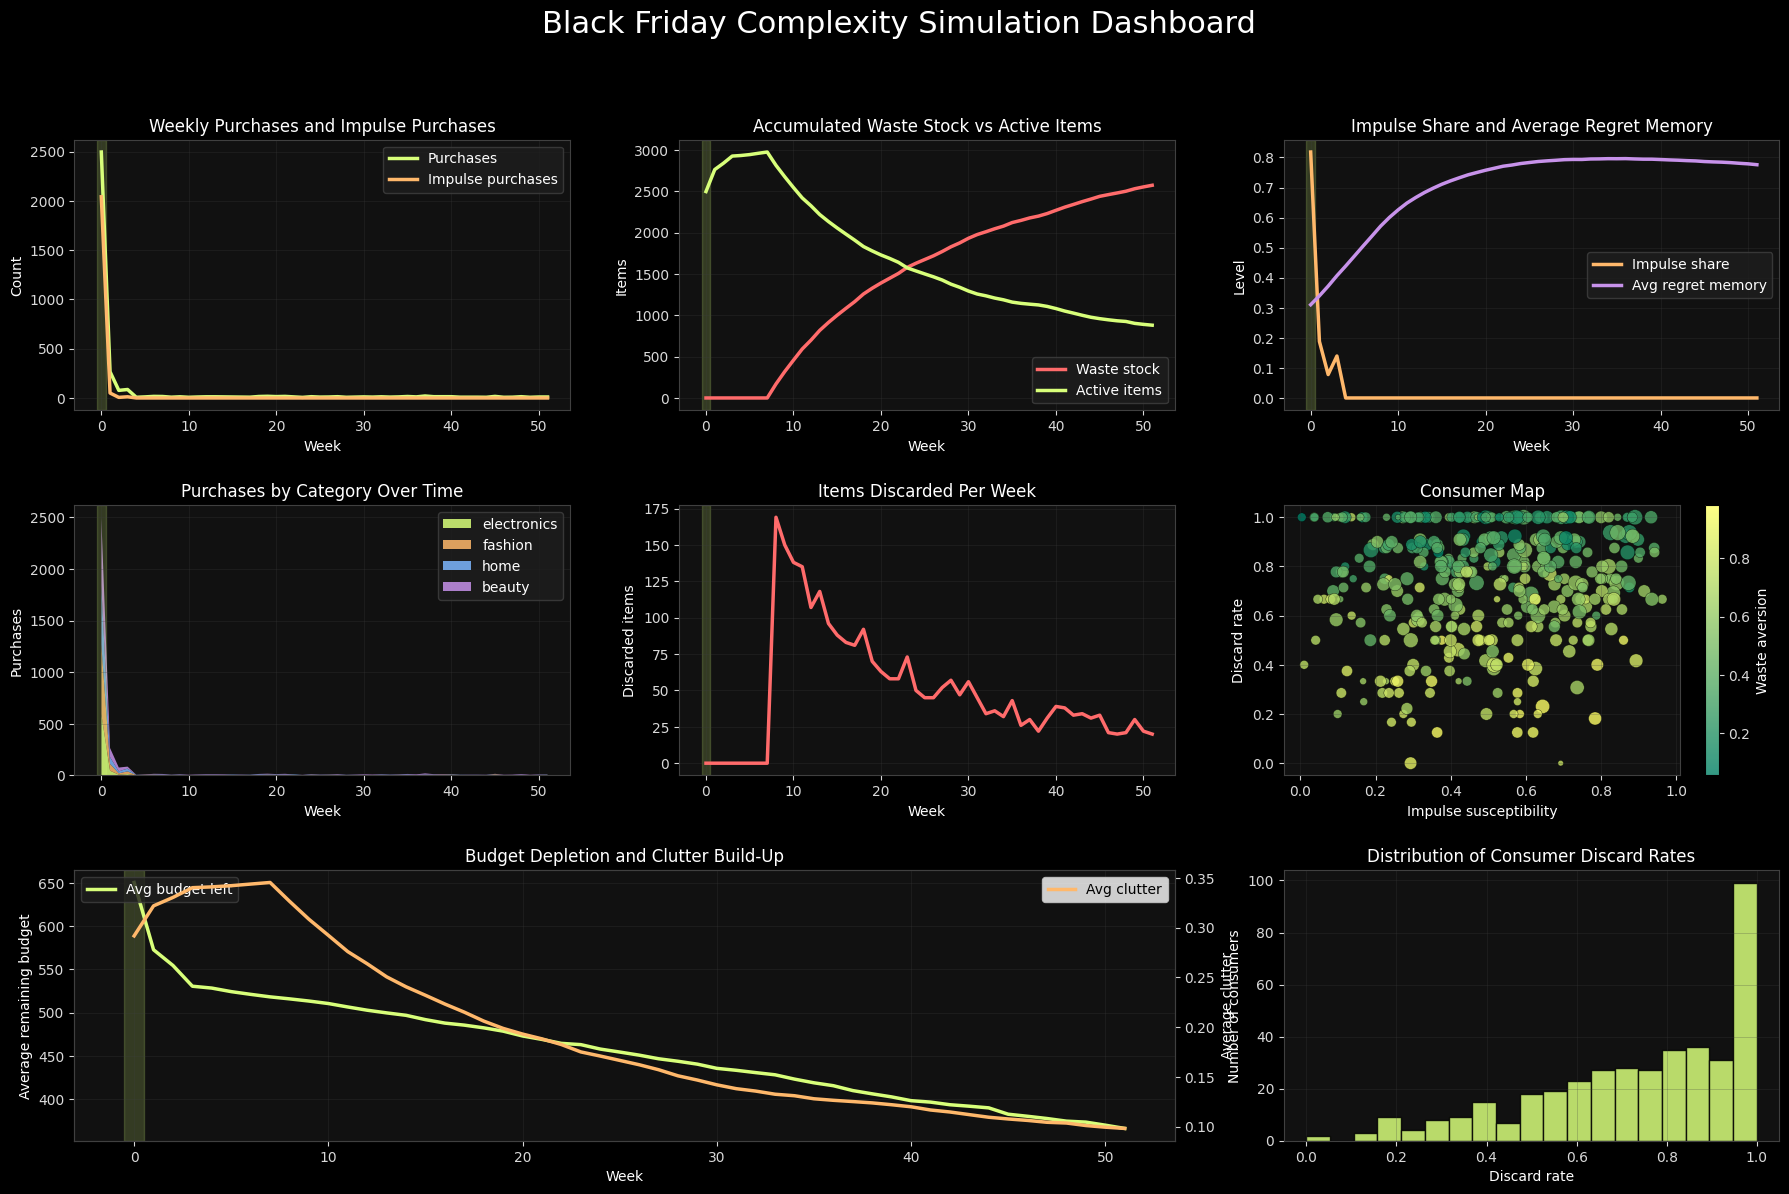

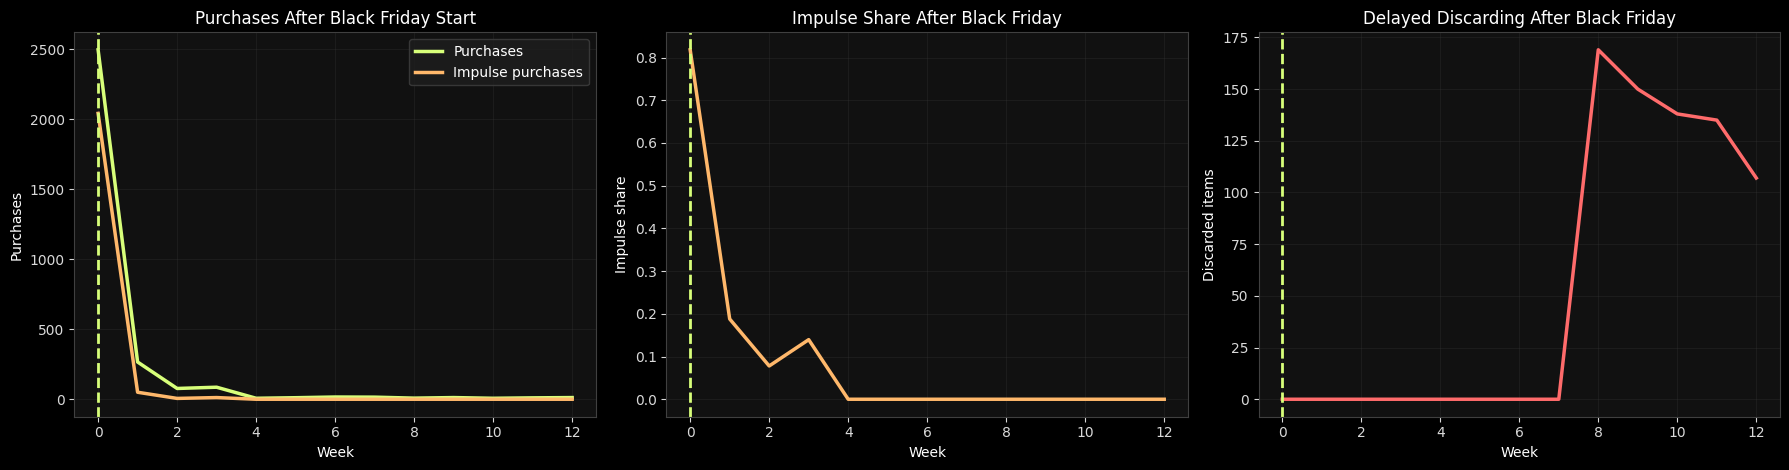

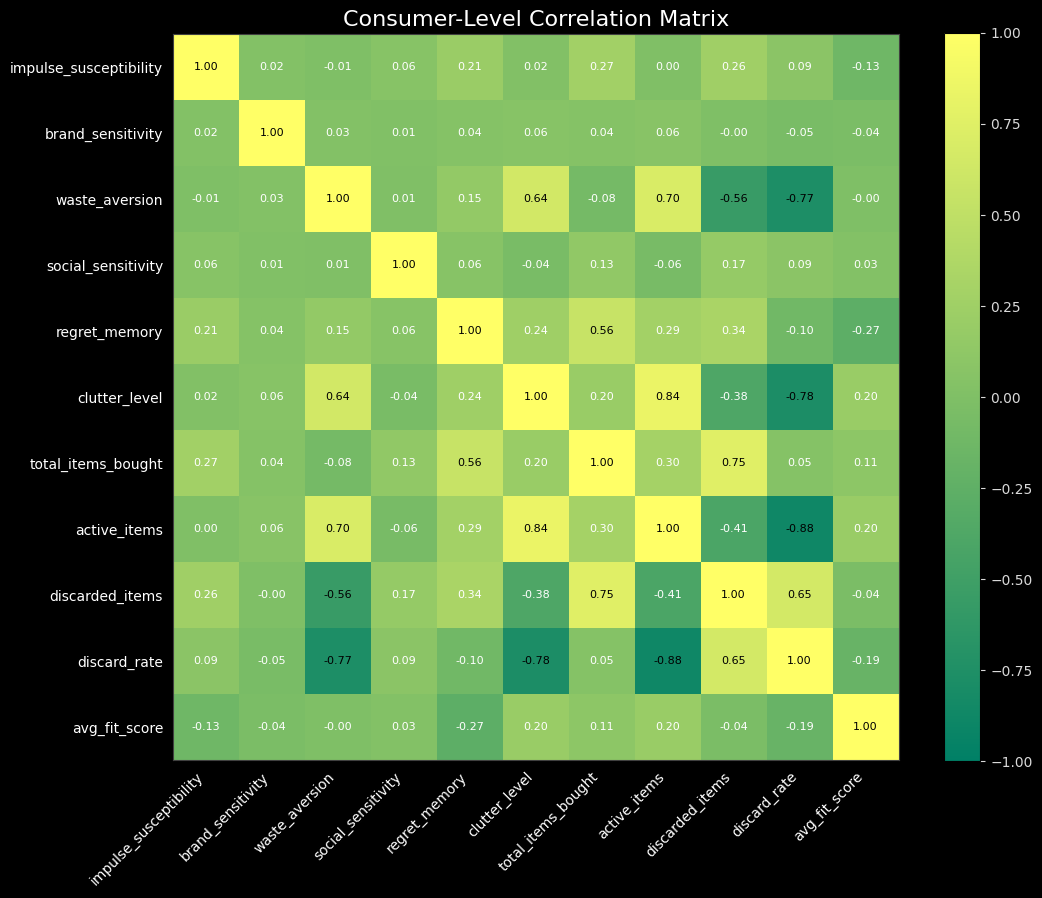

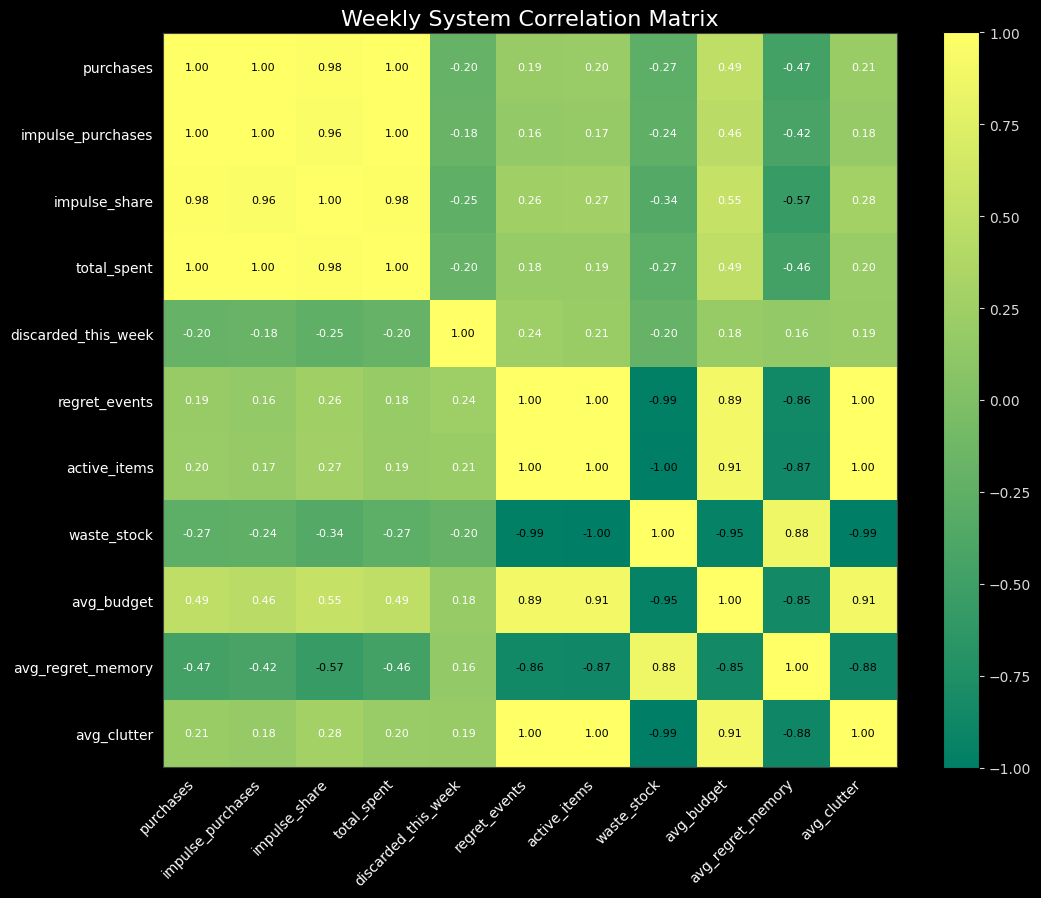

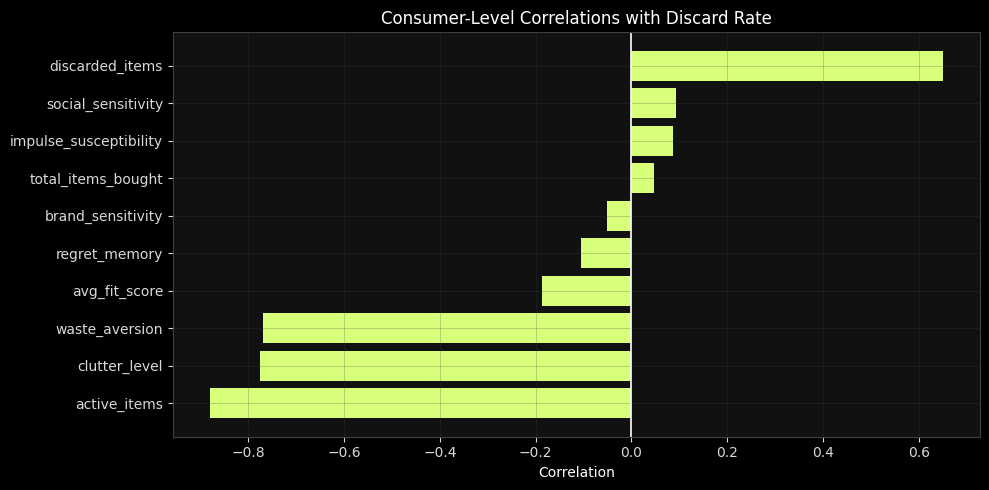

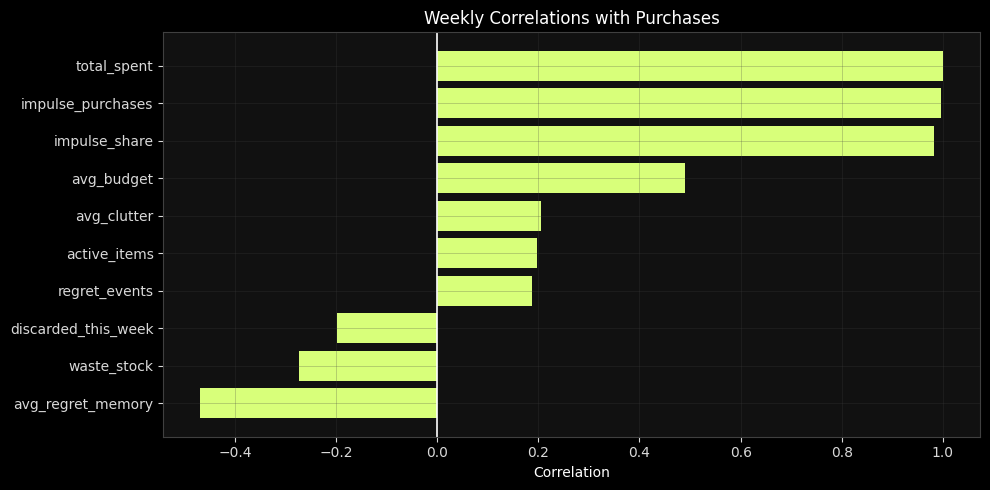

In [ ]:
# ----------------------------
# Run model
# ----------------------------

# Print the theoretical calibration notes once before the model runs.
# This is useful for the our report and presentation because it explains why the model values exist.
print_model_calibration_notes()

# Run the complete simulation using the default settings.
# By default this uses 400 consumers, 52 weeks and Black Friday at week 0.
results, consumers, products = run_simulation()

# Build the summary tables and correlation matrices used for interpretation.
consumer_df, consumer_corr, weekly_corr = make_correlation_tables(results, consumers)

print(results.head())

print("\nSummary")
print(
    results[
        [
            "purchases",
            "impulse_purchases",
            "impulse_share",
            "discarded_this_week",
            "waste_stock"
        ]
    ].describe()
)

print_key_correlations(consumer_corr, weekly_corr)

visualize_simulation(results, consumers)
plot_black_friday_start_window(results)

plot_correlation_matrix(consumer_corr, "Consumer-Level Correlation Matrix")
plot_correlation_matrix(weekly_corr, "Weekly System Correlation Matrix")
plot_key_correlation_bars(consumer_corr, weekly_corr)


In [11]:
# ----------------------------
# OLS regression analysis
# ----------------------------
# This section adds a simple Ordinary Least Squares regression to the simulation.
# OLS is useful here because I can test whether weekly system variables such as
# purchases, impulse buying, regret, and clutter are associated with waste.
# The model does not prove causality, because the data is generated by the simulation,
# but it helps summarise which variables move together.

import statsmodels.api as sm


def run_weekly_ols(results):
    """
    Run an OLS regression on weekly simulation outcomes.

    Dependent variable:
    - discarded_this_week: how many items were discarded in each week.

    Independent variables:
    - black_friday_week: whether the week is Black Friday week.
    - purchases: total number of purchases that week.
    - impulse_share: share of purchases classified as impulse purchases.
    - total_spent: total money spent that week.
    - regret_events: number of regret events that week.
    - avg_clutter: average clutter level among consumers.
    - avg_regret_memory: average accumulated regret among consumers.
    """

    y = results["discarded_this_week"]

    X = results[
        [
            "black_friday_week",
            "purchases",
            "impulse_share",
            "total_spent",
            "regret_events",
            "avg_clutter",
            "avg_regret_memory"
        ]
    ]

    # I add a constant so the regression has an intercept.
    X = sm.add_constant(X)

    weekly_ols_model = sm.OLS(y, X).fit()

    print("\nOLS regression predicting weekly discarded items")
    print(weekly_ols_model.summary())

    return weekly_ols_model


def run_consumer_ols(consumer_df):
    """
    Run an OLS regression on consumer-level outcomes.

    Dependent variable:
    - discard_rate: the share of a consumer's bought items that were discarded.

    Independent variables:
    - impulse_susceptibility: how easily the consumer buys impulsively.
    - brand_sensitivity: how strongly brand reputation affects the consumer.
    - waste_aversion: how much the consumer avoids wasting products.
    - social_sensitivity: how strongly social hype affects the consumer.
    - regret_memory: how much regret the consumer has accumulated.
    - clutter_level: how full the consumer's storage is.
    - total_items_bought: total number of items bought by the consumer.
    - avg_fit_score: average fit between the consumer and their bought products.
    """

    y = consumer_df["discard_rate"]

    X = consumer_df[
        [
            "impulse_susceptibility",
            "brand_sensitivity",
            "waste_aversion",
            "social_sensitivity",
            "regret_memory",
            "clutter_level",
            "total_items_bought",
            "avg_fit_score"
        ]
    ]

    # I add a constant so the regression has an intercept.
    X = sm.add_constant(X)

    consumer_ols_model = sm.OLS(y, X).fit()

    print("\nOLS regression predicting consumer discard rate")
    print(consumer_ols_model.summary())

    return consumer_ols_model


weekly_ols_model = run_weekly_ols(results)
consumer_ols_model = run_consumer_ols(consumer_df)



OLS regression predicting weekly discarded items
                             OLS Regression Results                            
Dep. Variable:     discarded_this_week   R-squared:                       0.715
Model:                             OLS   Adj. R-squared:                  0.670
Method:                  Least Squares   F-statistic:                     15.77
Date:                 Fri, 29 May 2026   Prob (F-statistic):           3.79e-10
Time:                         12:29:32   Log-Likelihood:                -233.47
No. Observations:                   52   AIC:                             482.9
Df Residuals:                       44   BIC:                             498.6
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

In [12]:
weekly_ols_model = run_weekly_ols(results)
consumer_ols_model = run_consumer_ols(consumer_df)


OLS regression predicting weekly discarded items
                             OLS Regression Results                            
Dep. Variable:     discarded_this_week   R-squared:                       0.715
Model:                             OLS   Adj. R-squared:                  0.670
Method:                  Least Squares   F-statistic:                     15.77
Date:                 Fri, 29 May 2026   Prob (F-statistic):           3.79e-10
Time:                         12:29:32   Log-Likelihood:                -233.47
No. Observations:                   52   AIC:                             482.9
Df Residuals:                       44   BIC:                             498.6
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

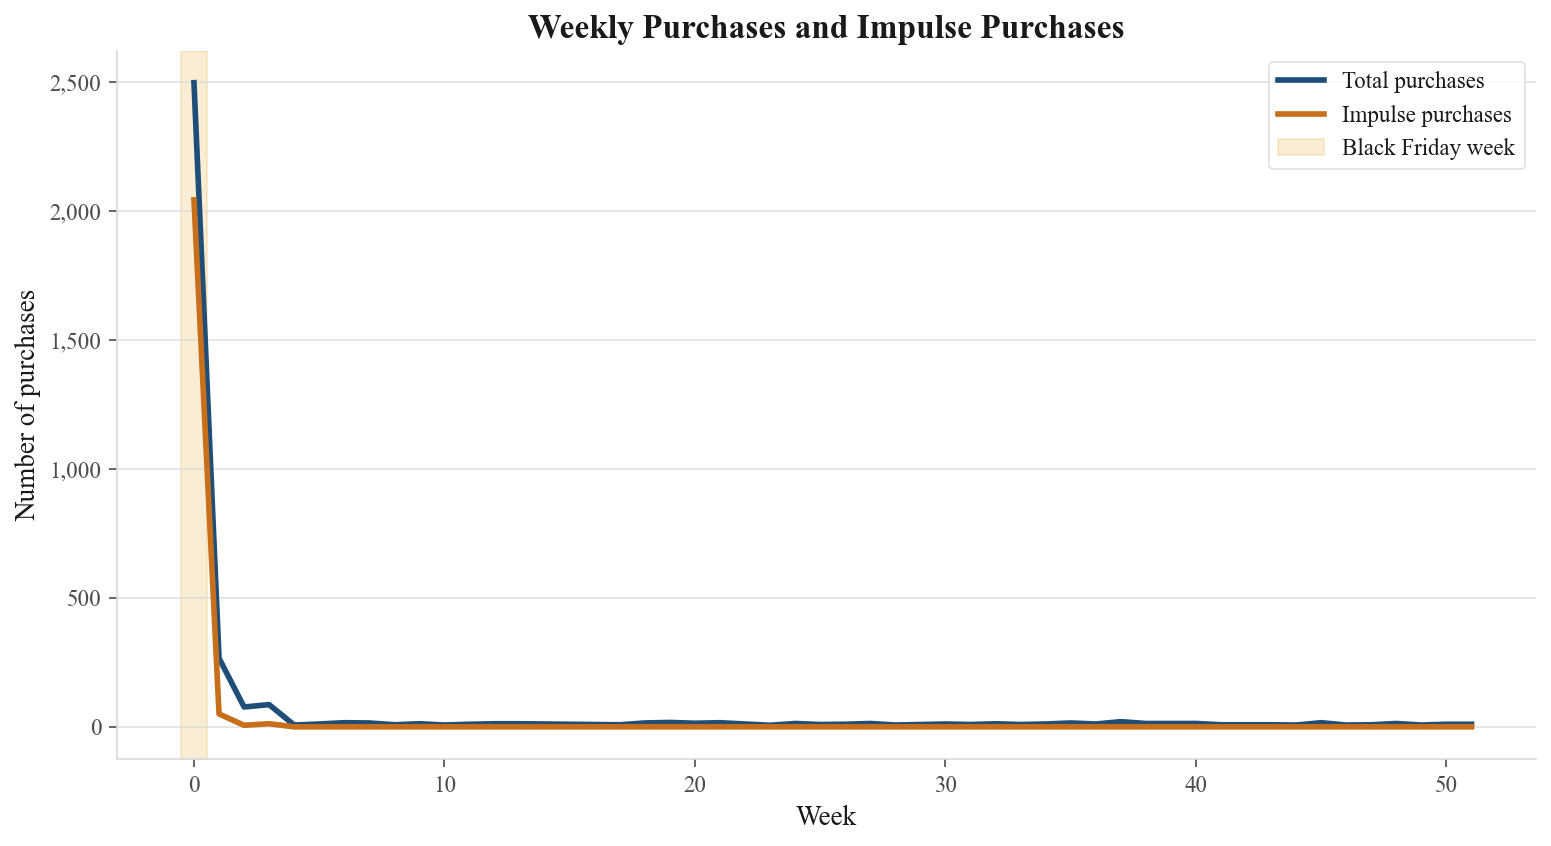

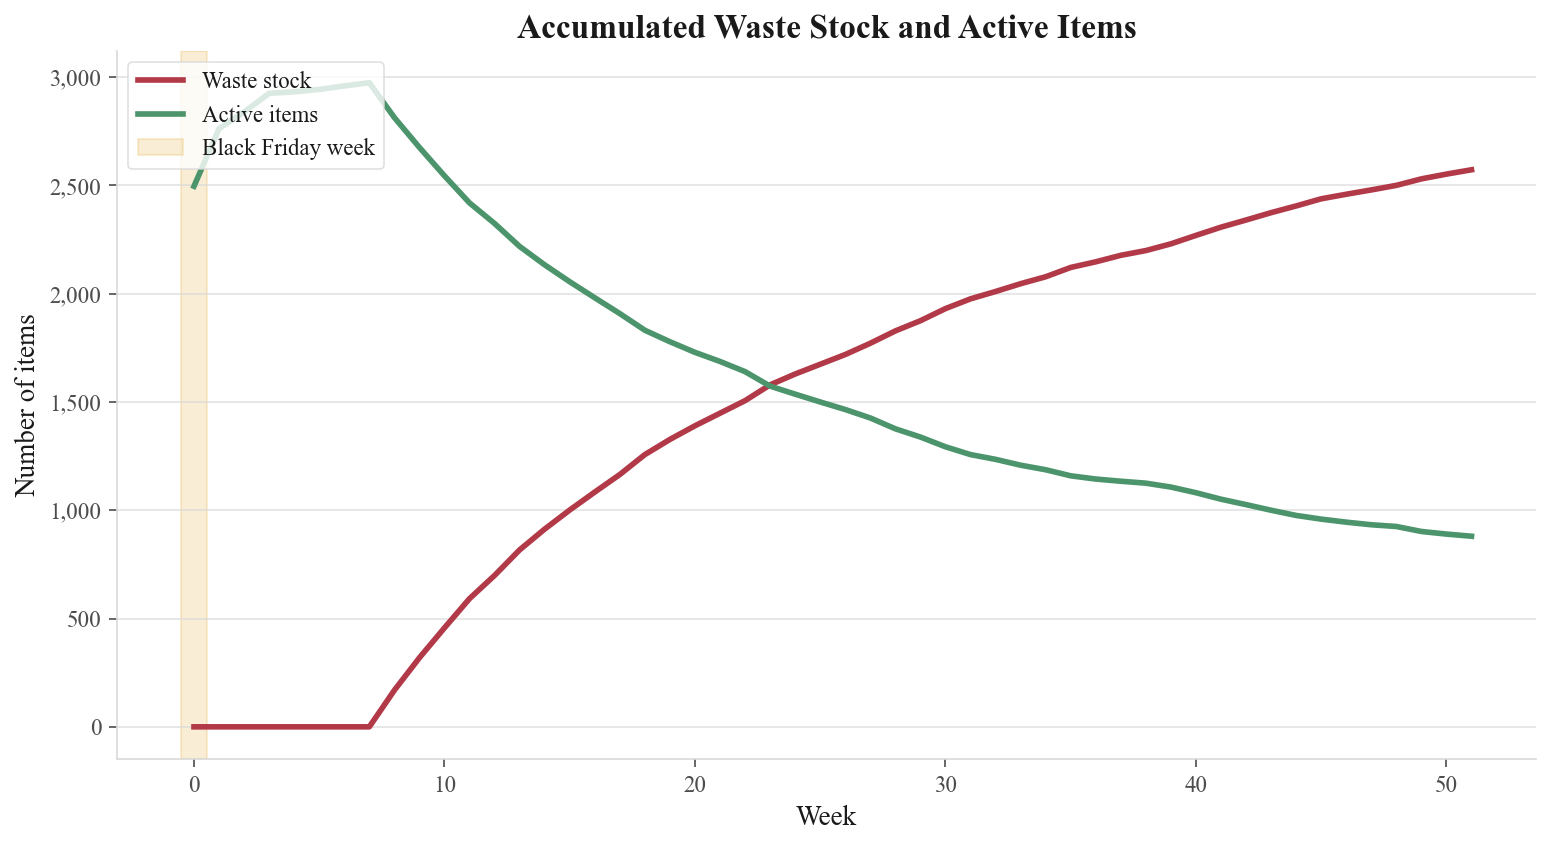

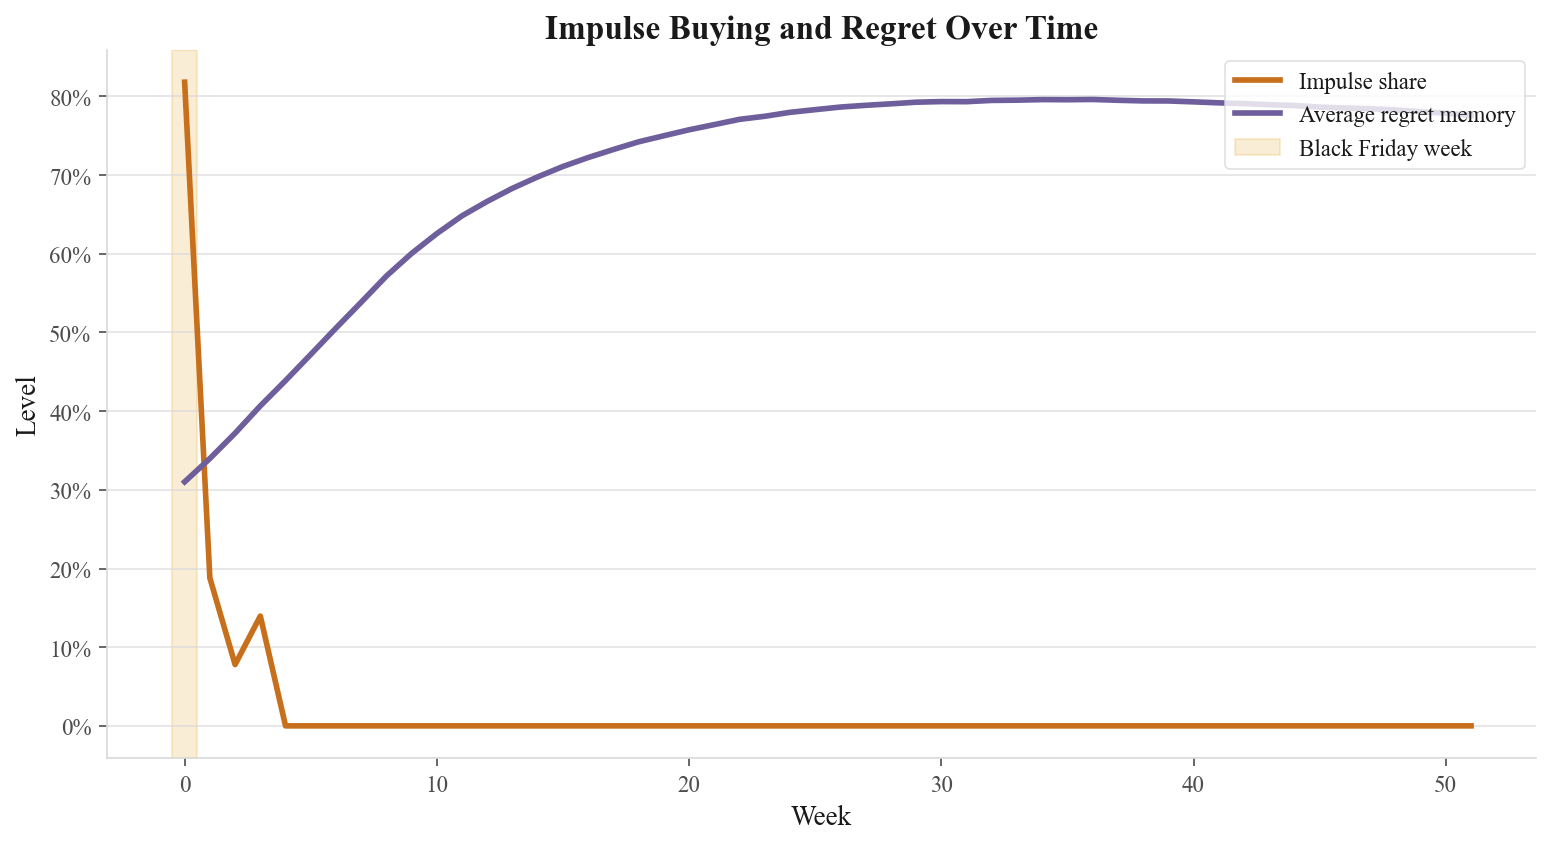

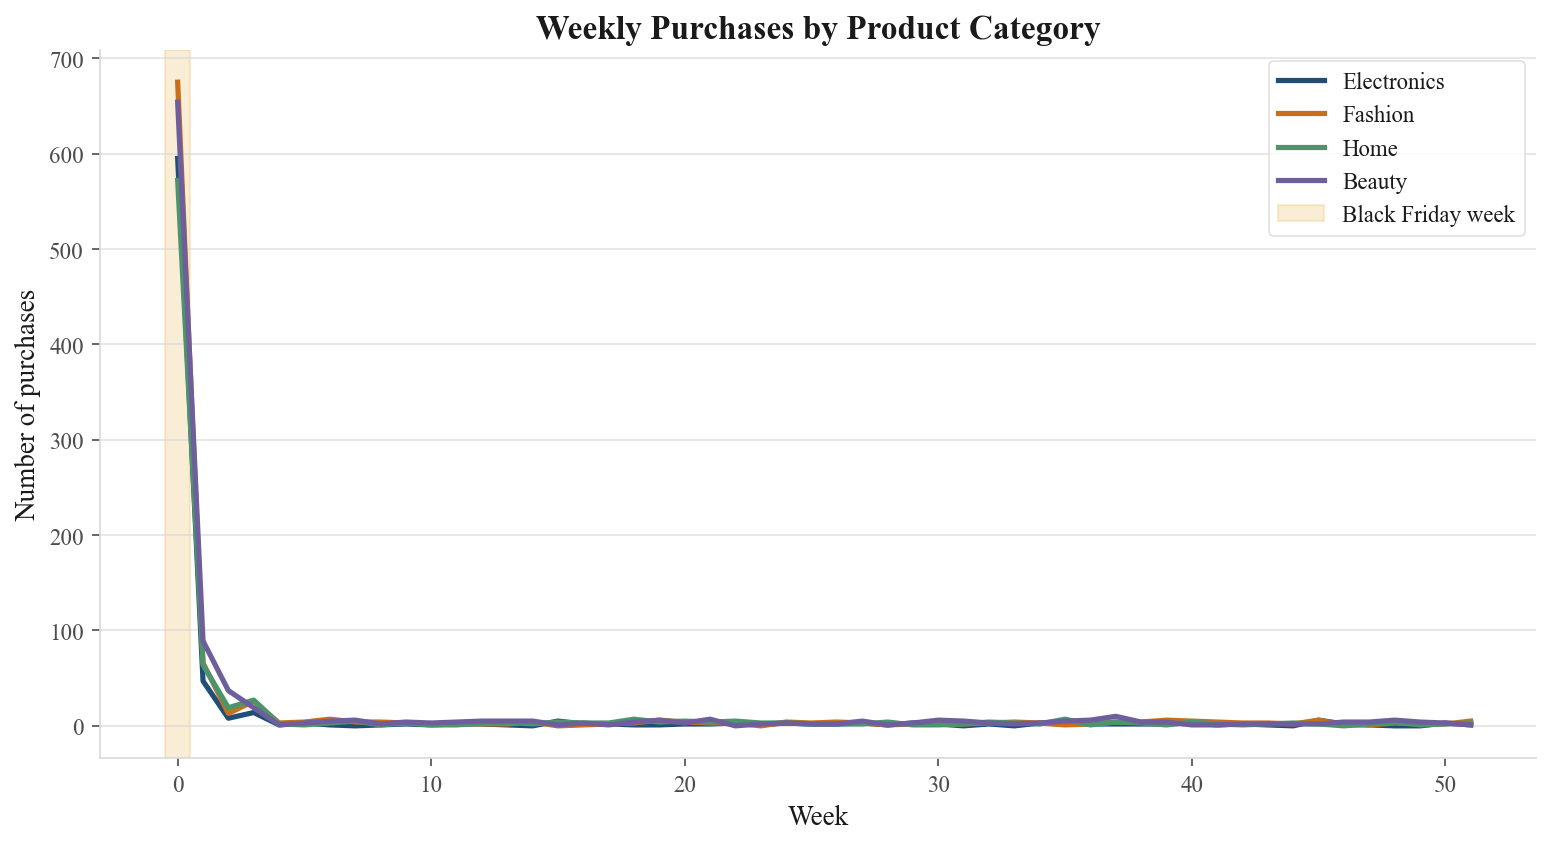

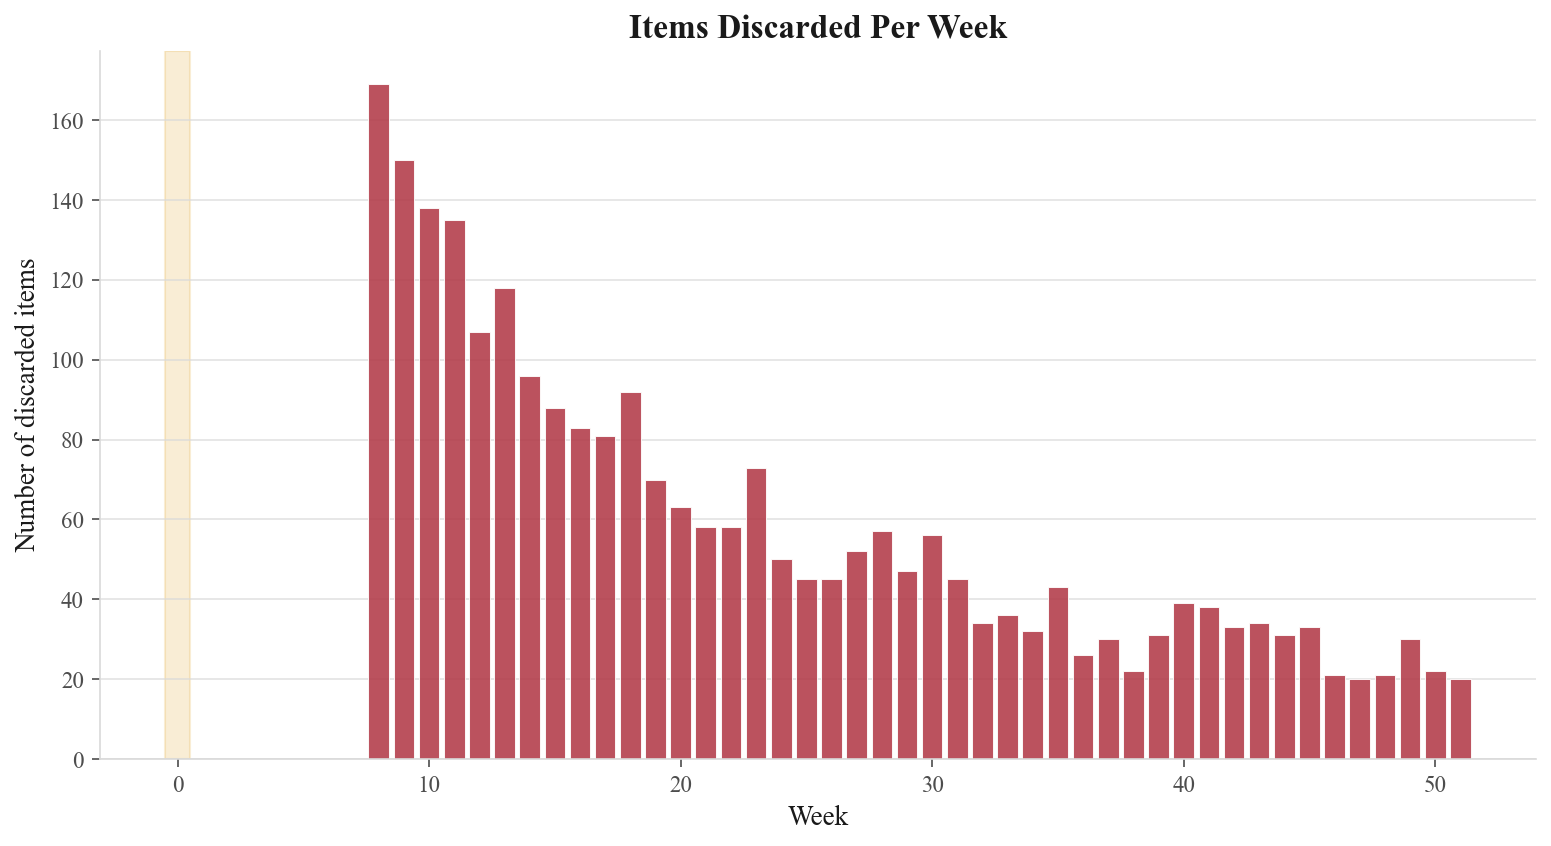

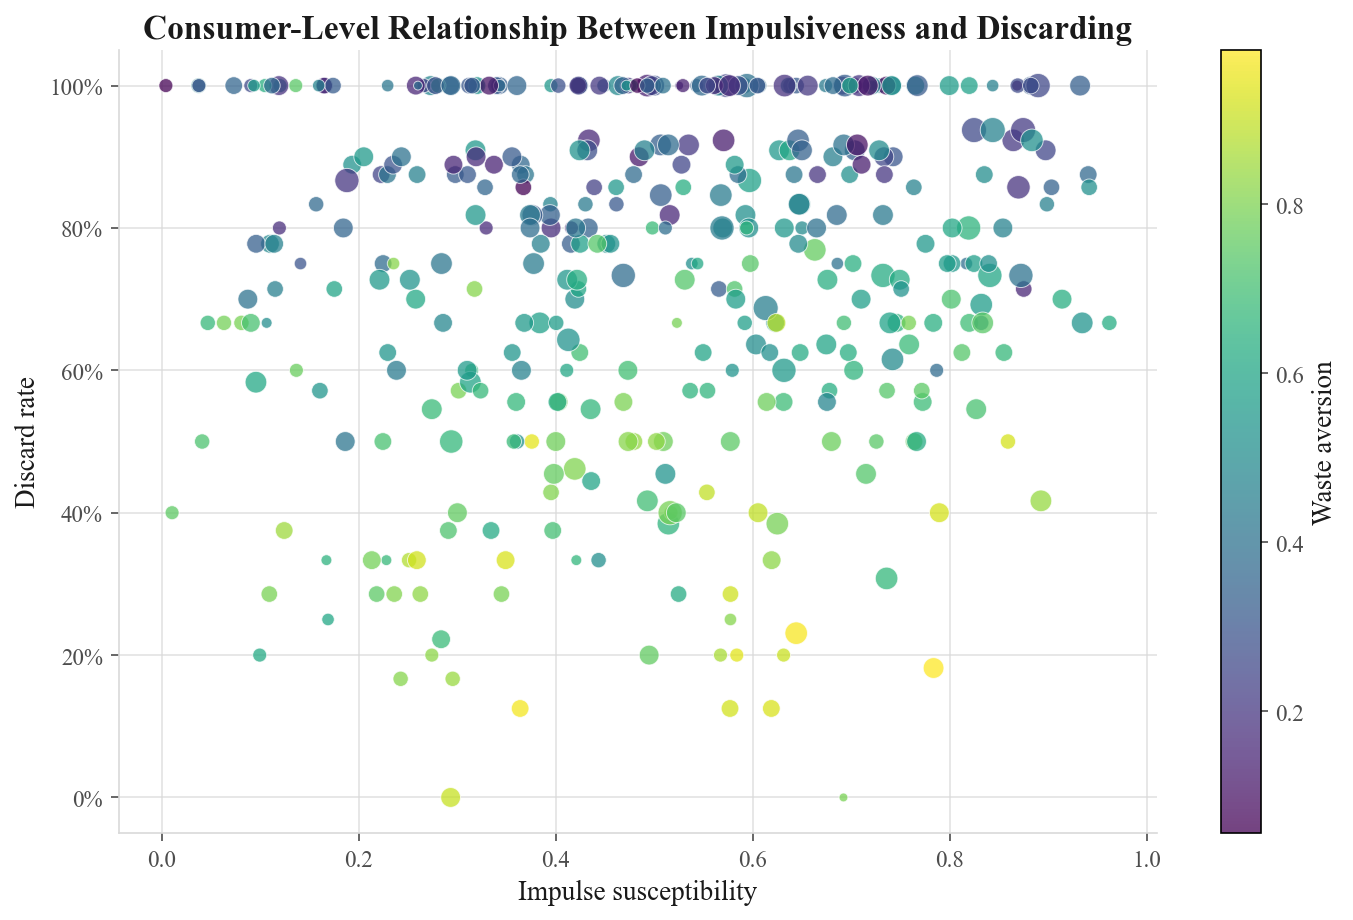

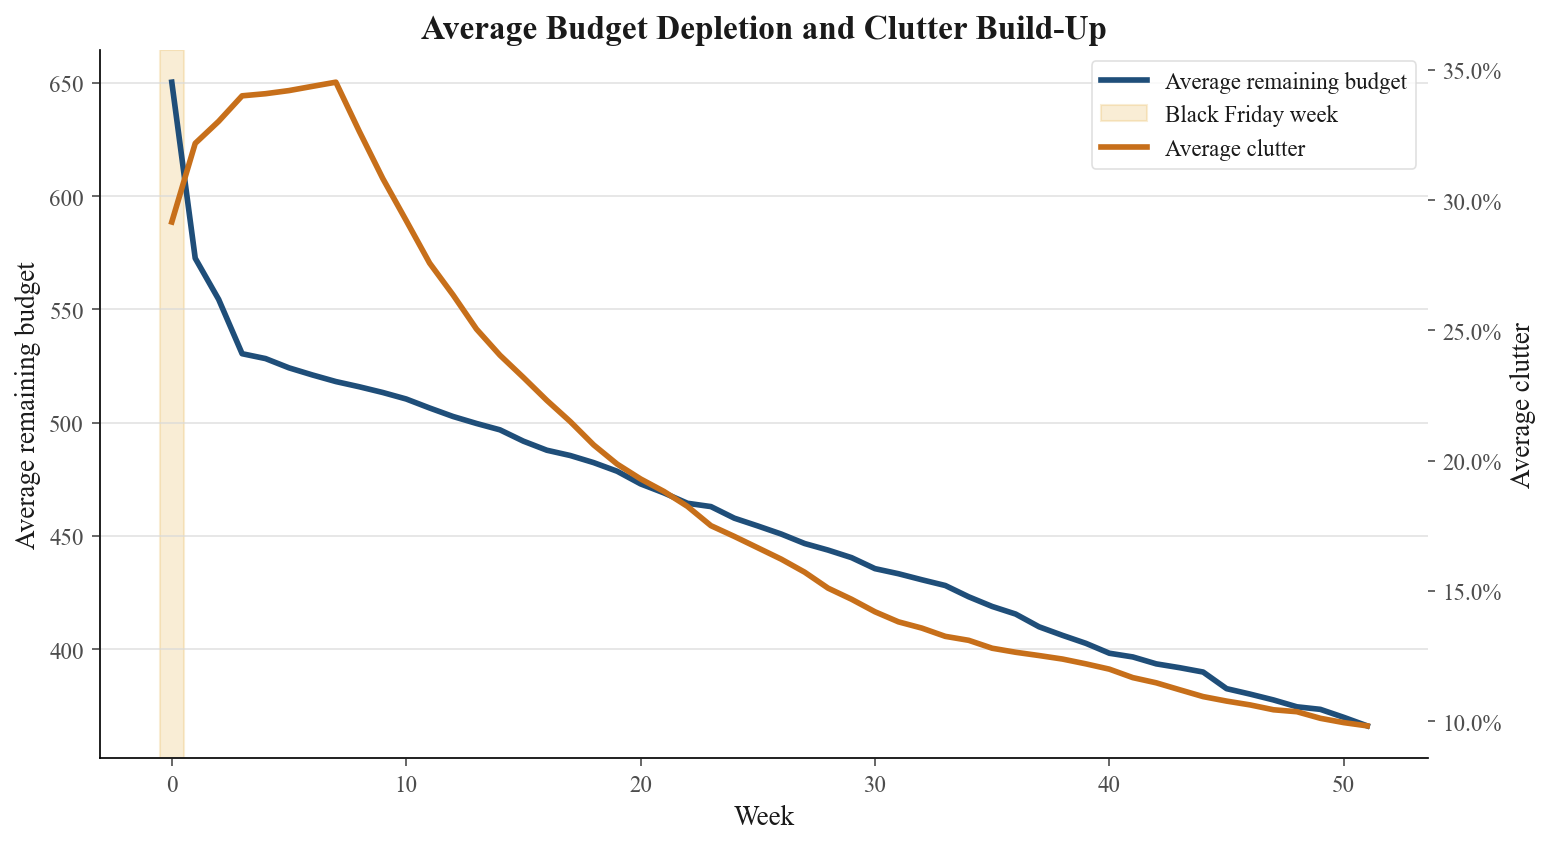

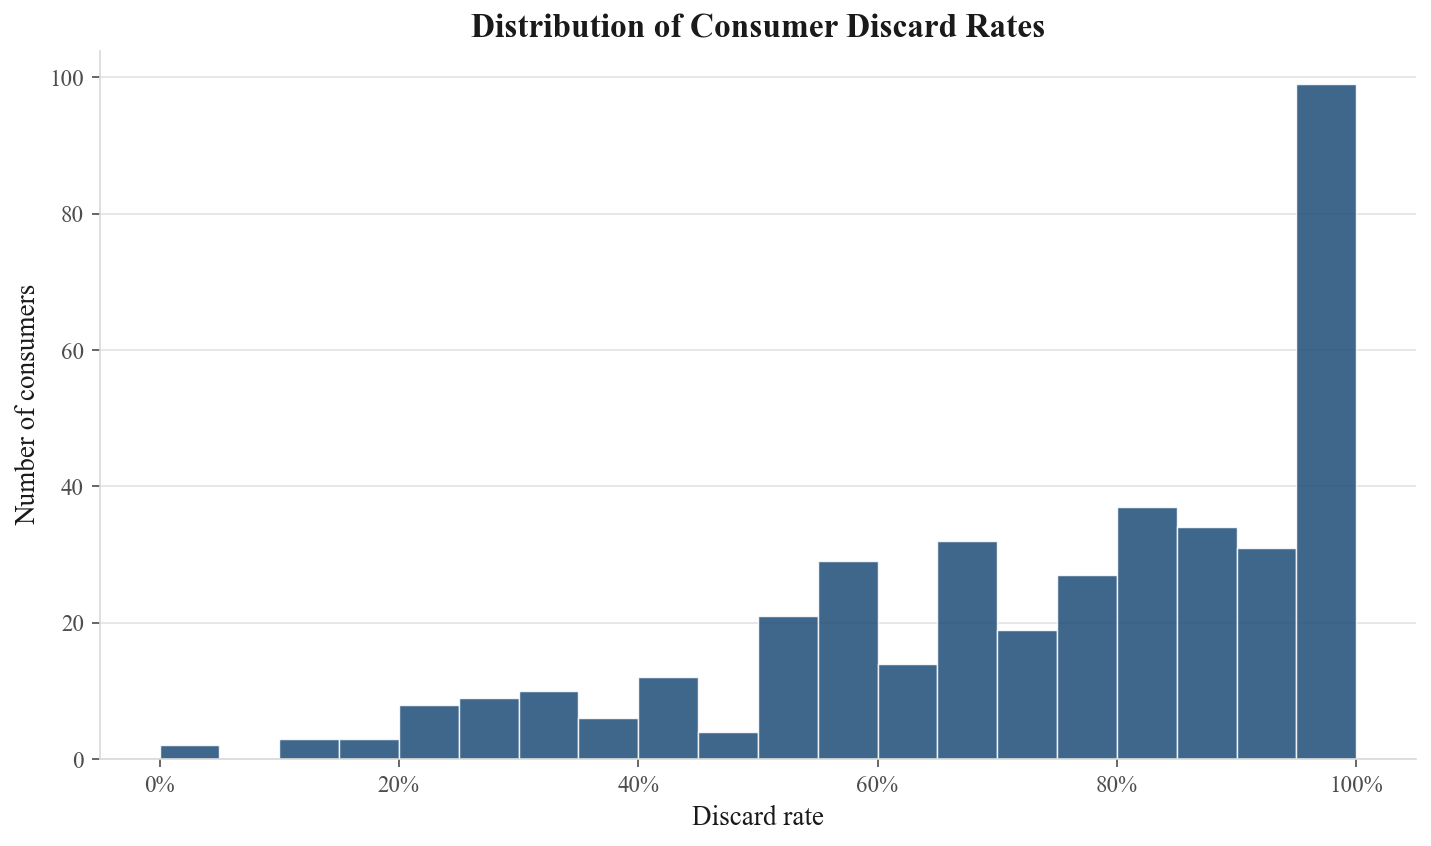

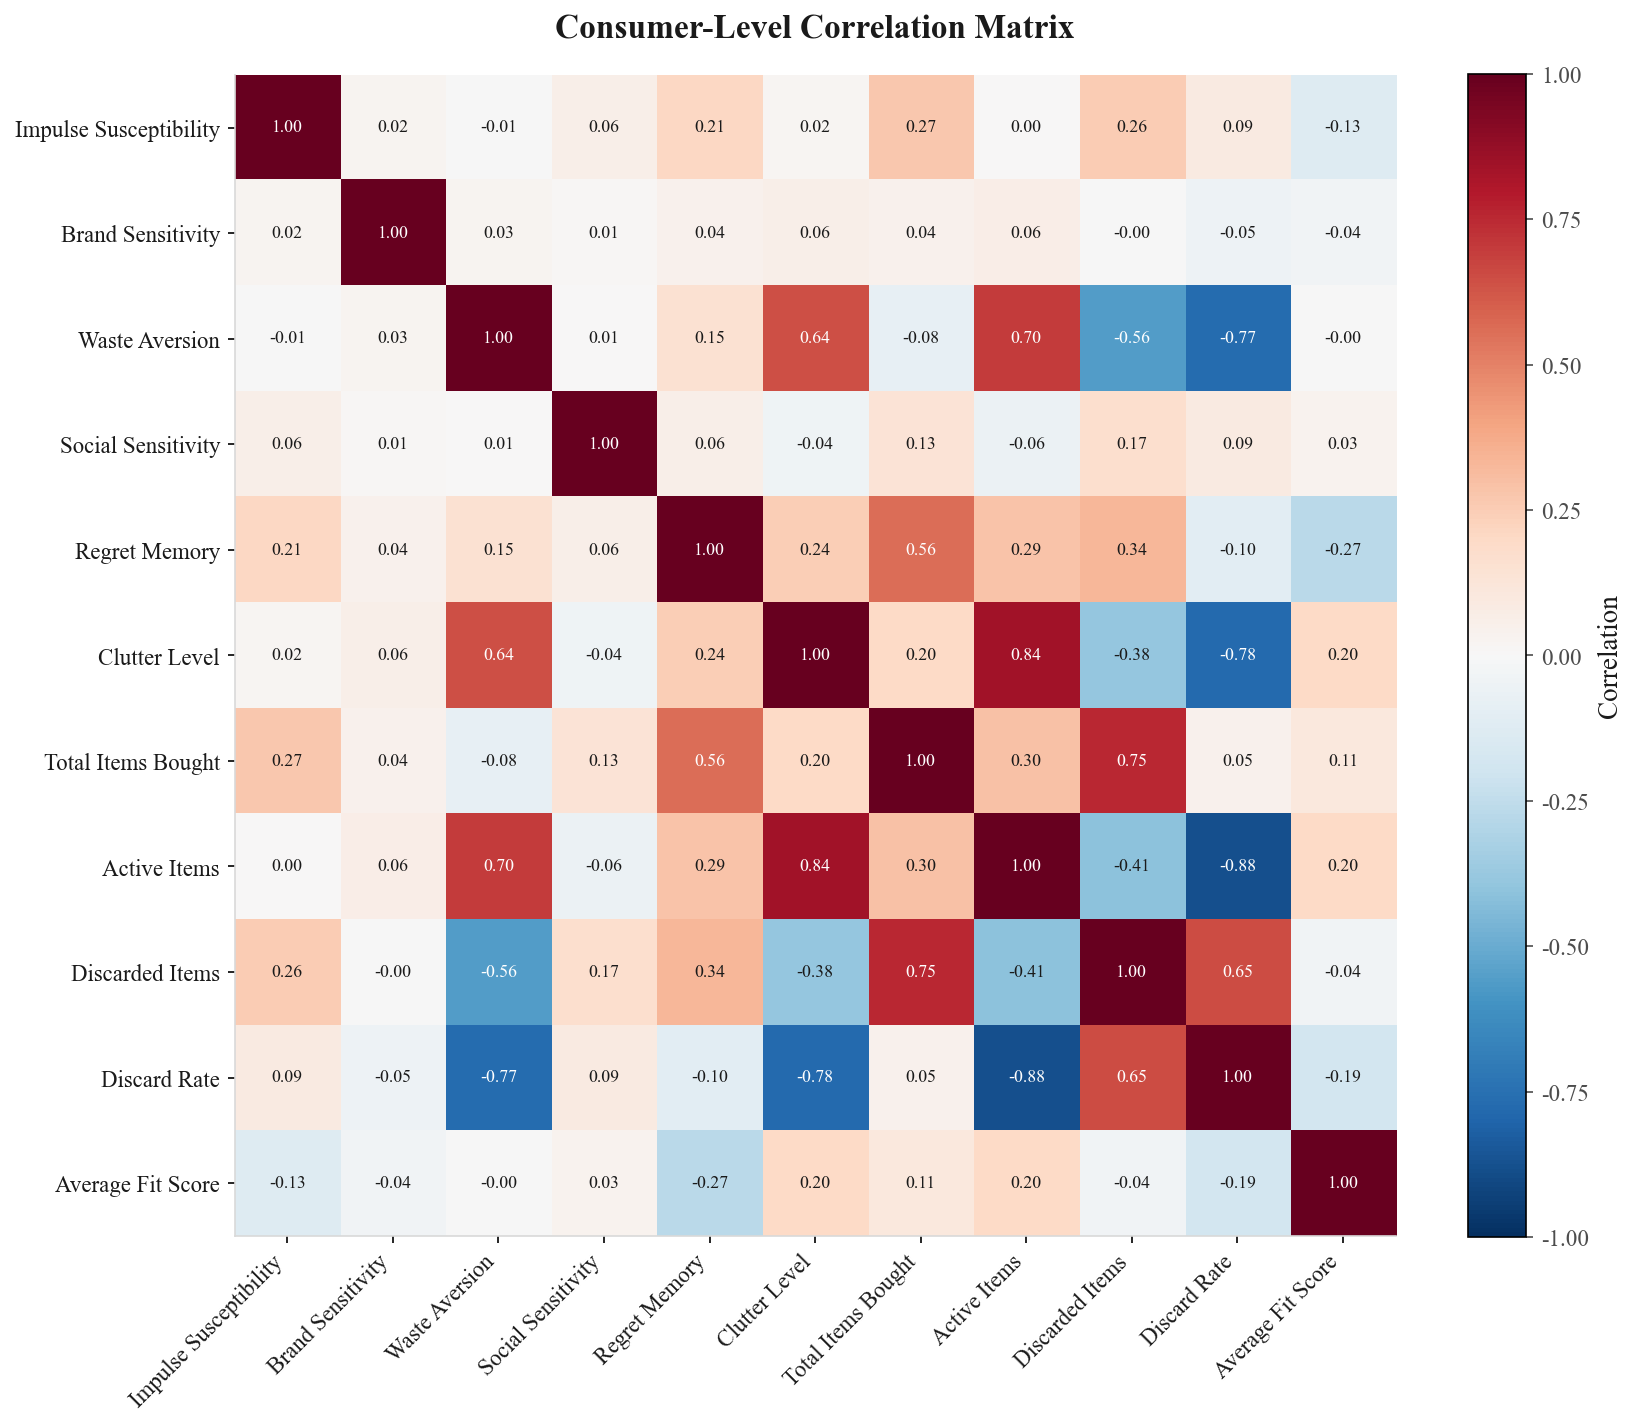

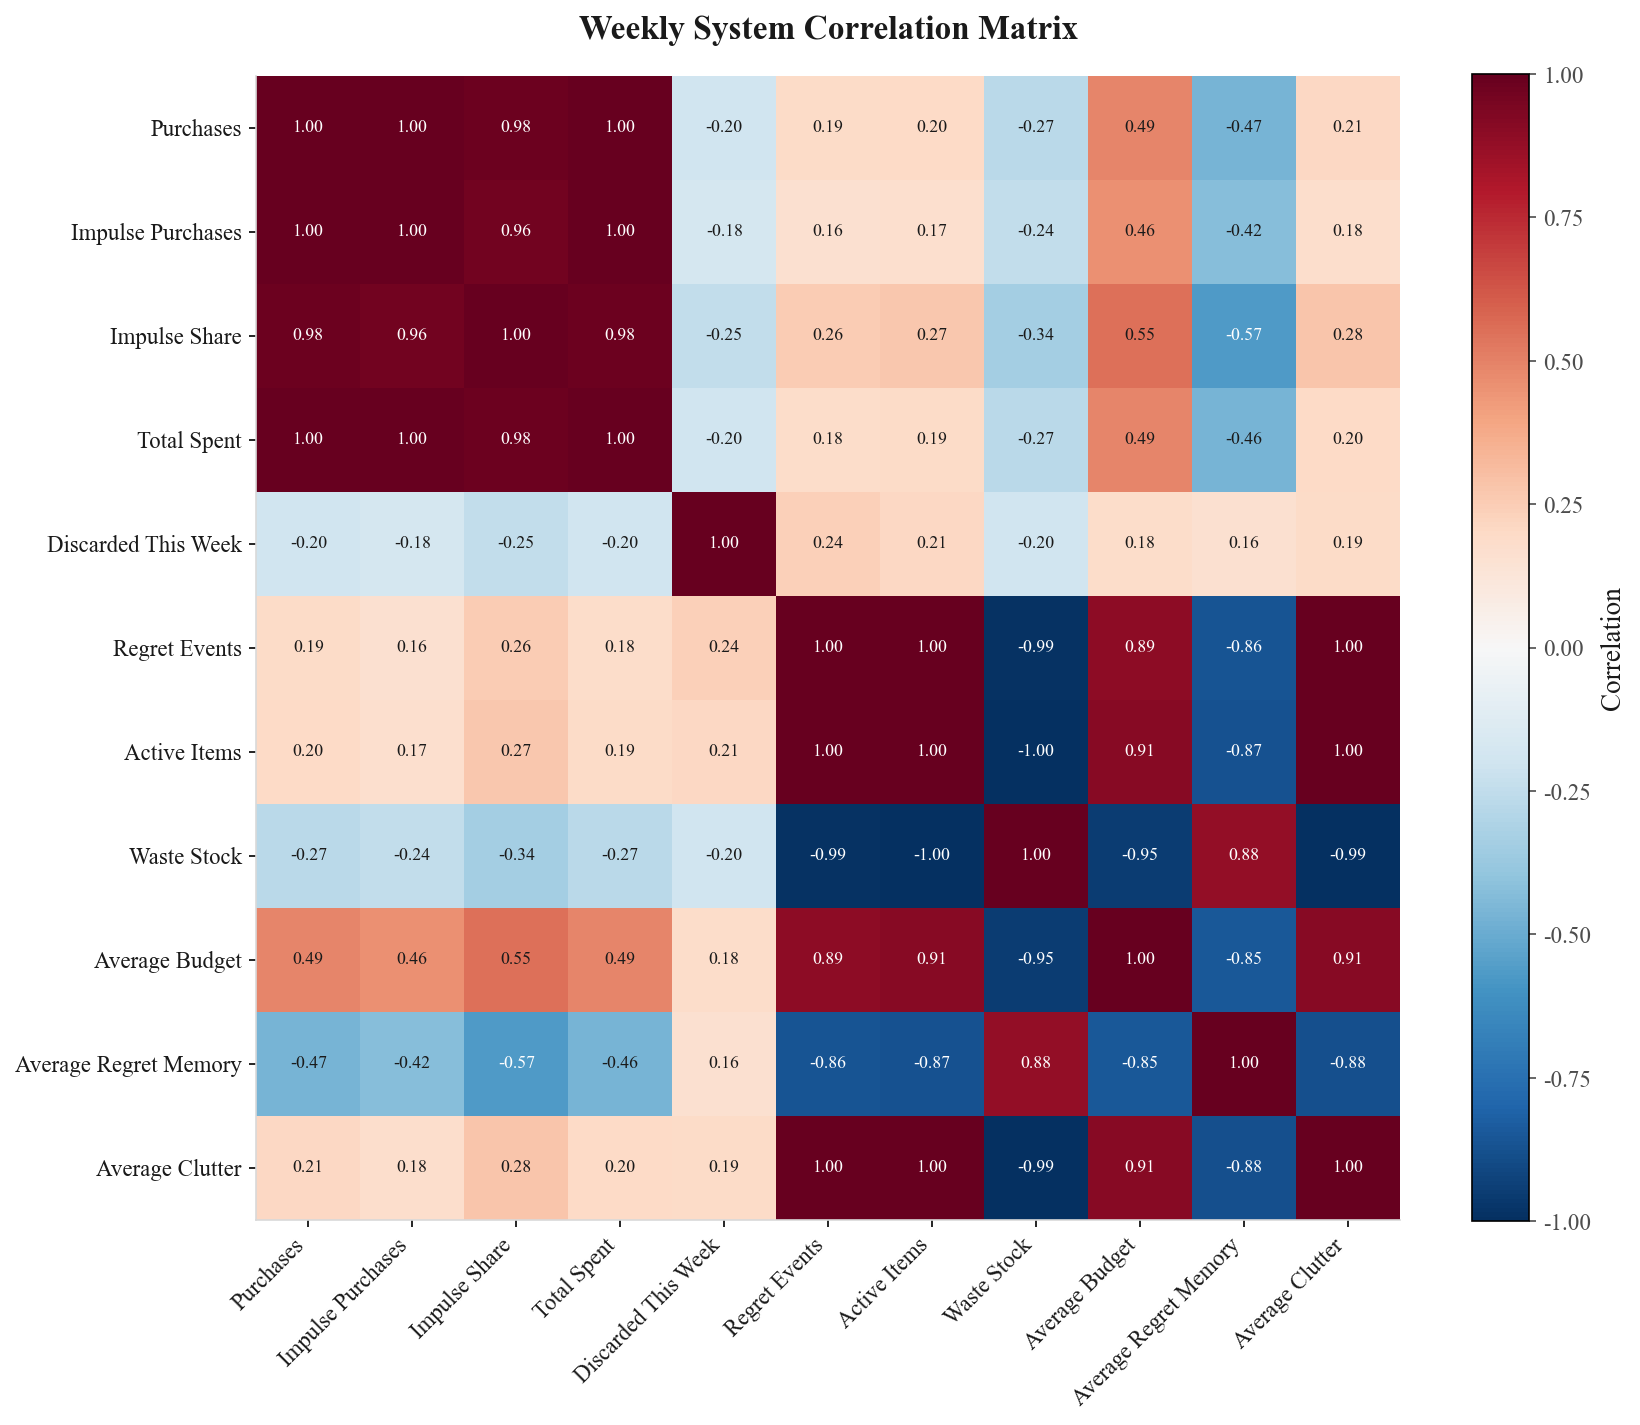

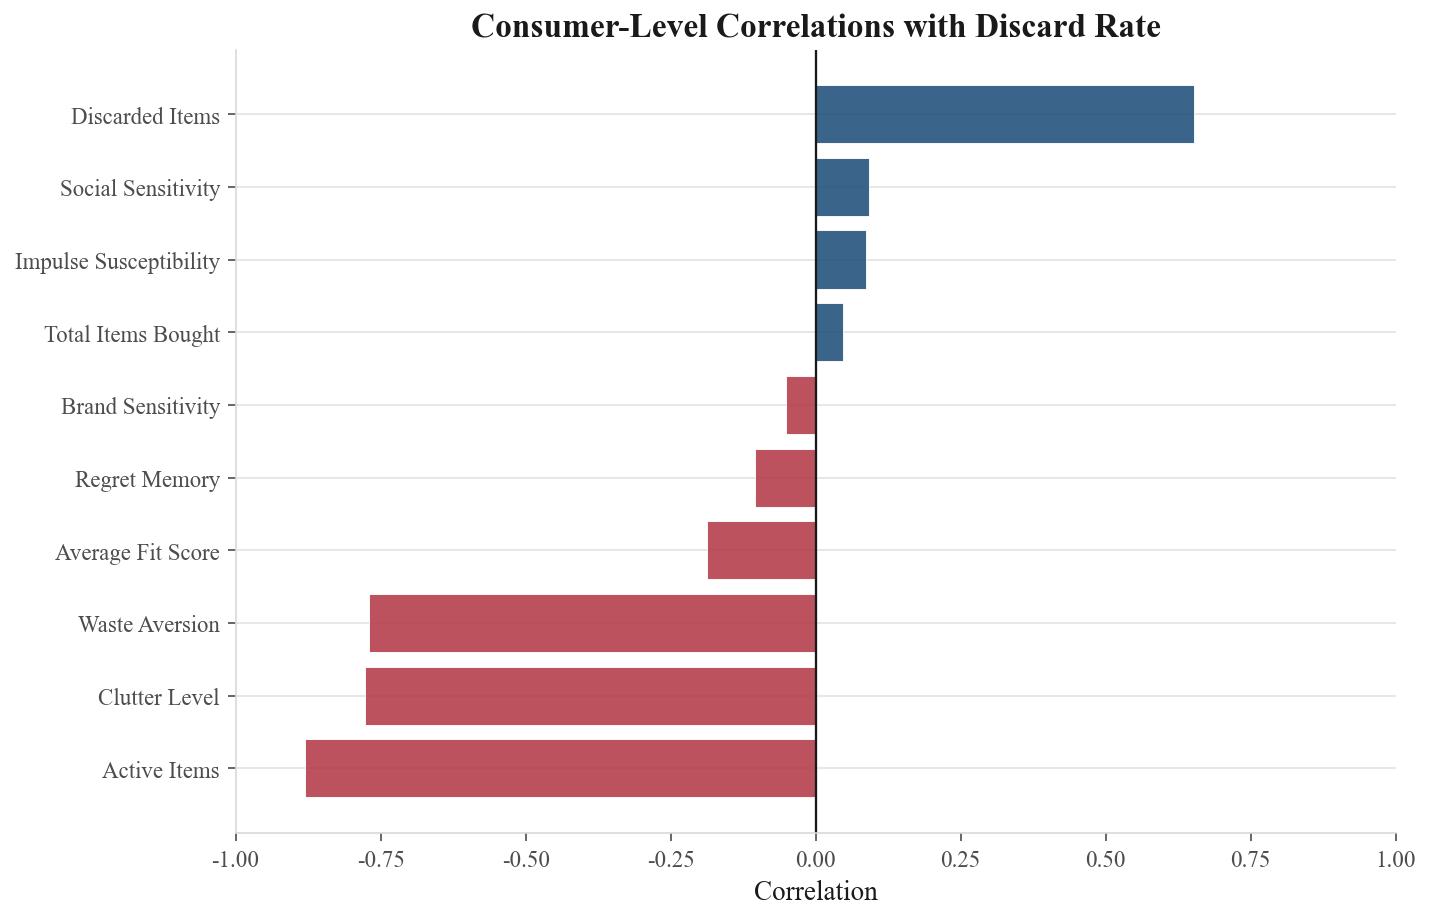

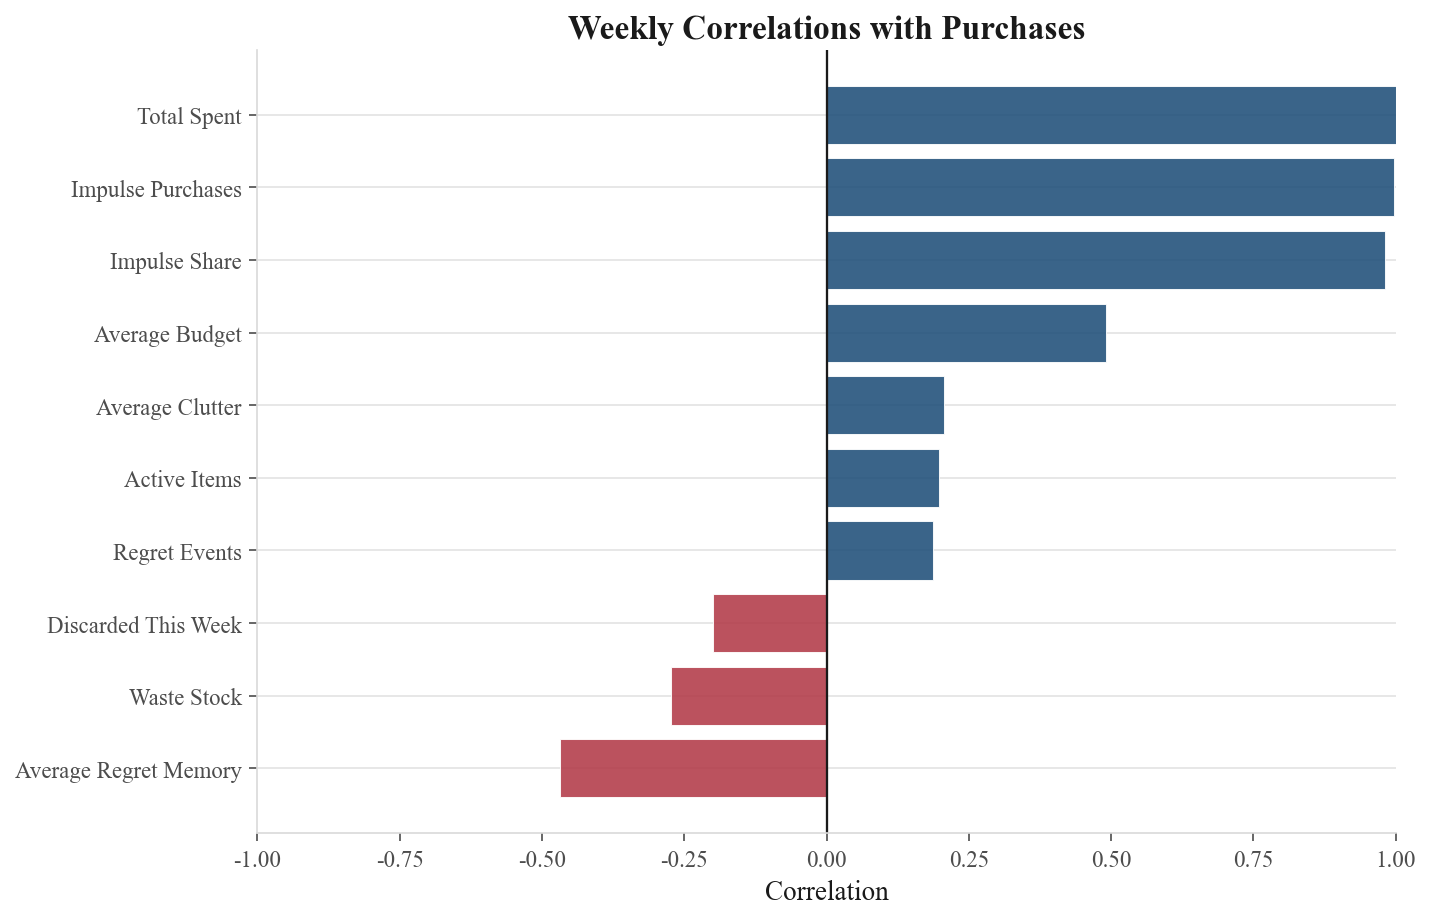

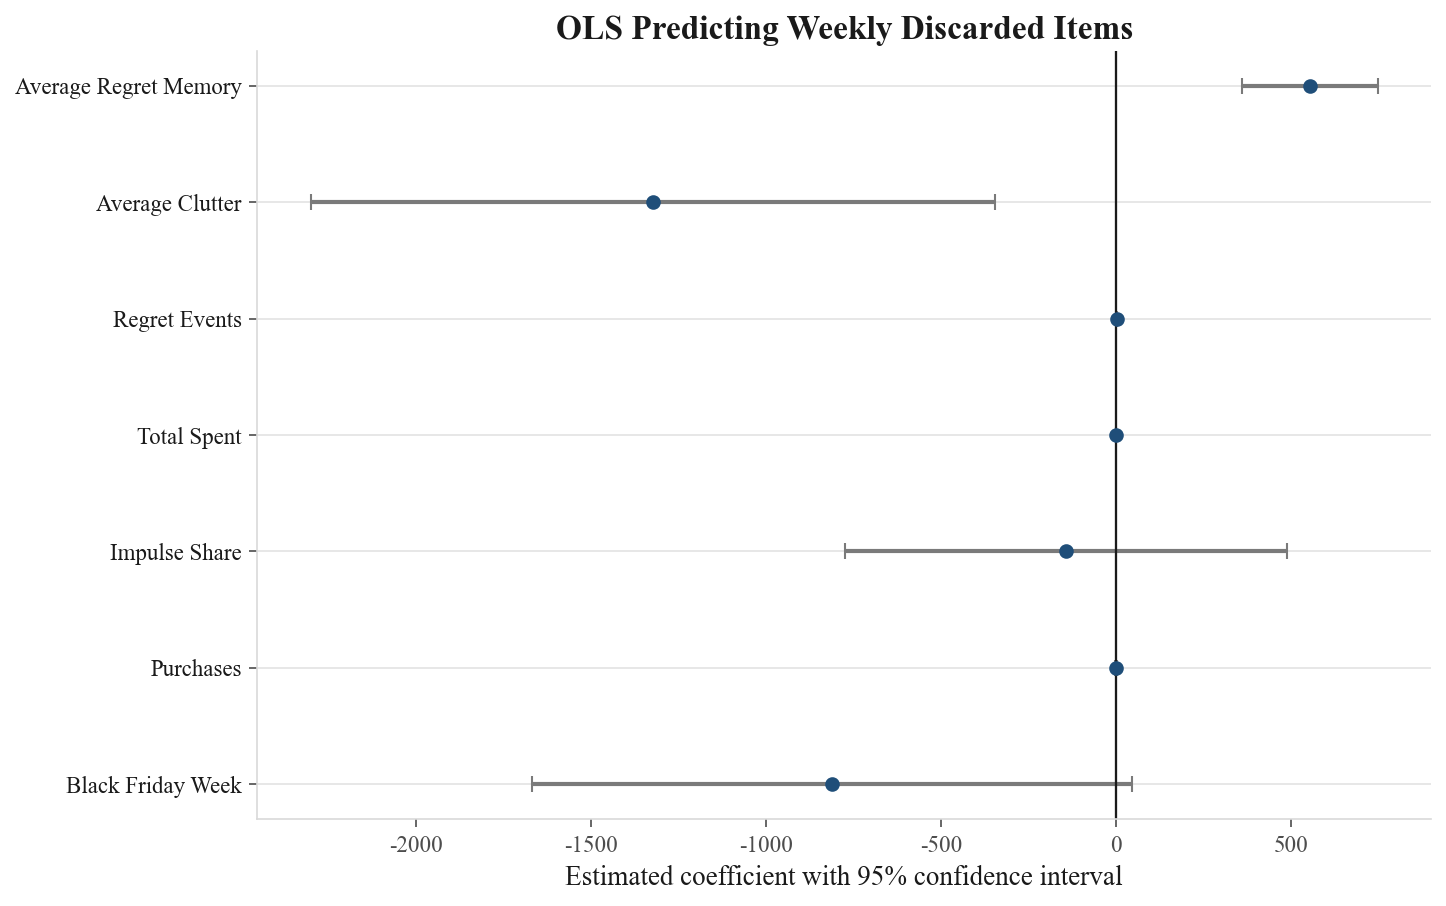

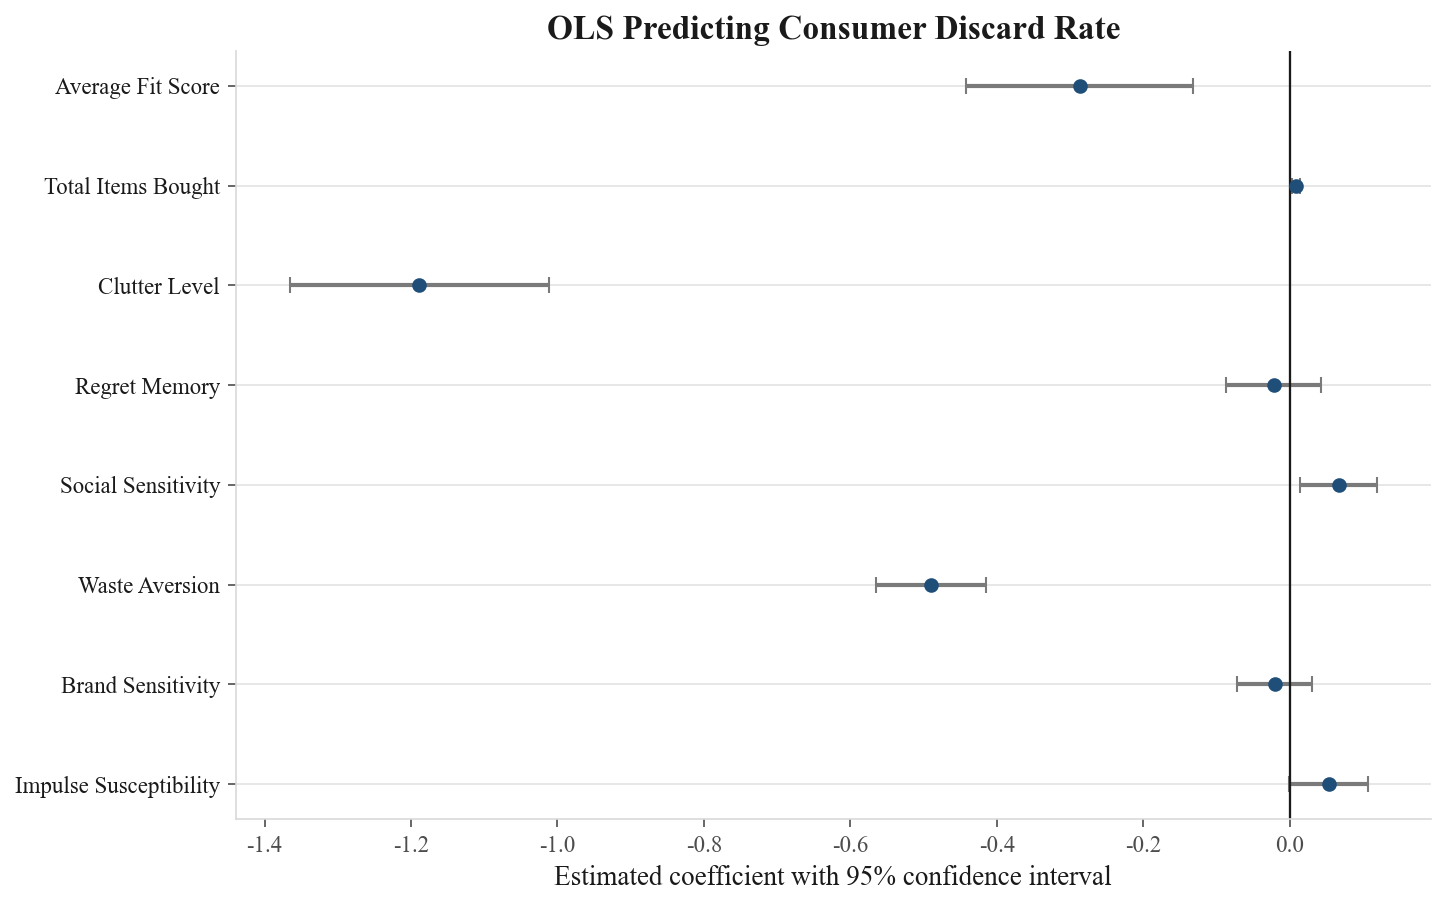

In [13]:
# Here I make the graphs for the report, instead of using the same as for the presentation. 
# ----------------------------
# Publication-level individual graphs
# White background, Times New Roman, consistent academic colour palette
# ----------------------------

import matplotlib.ticker as mtick
from pathlib import Path

SAVE_GRAPHS = False
GRAPH_FOLDER = "publication_level_graphs"

#
# The same colours are reused across all figures so the visual language stays consistent.
JOURNAL_COLORS = {
    "background": "#FFFFFF",
    "panel": "#FFFFFF",
    "text": "#1A1A1A",
    "muted_text": "#4D4D4D",
    "grid": "#D9D9D9",
    "primary_blue": "#1F4E79",
    "burnt_orange": "#C76F1A",
    "muted_green": "#4C956C",
    "muted_red": "#B23A48",
    "muted_purple": "#6F5E9C",
    "gold": "#E6B450",
    "grey": "#7A7A7A",
    "light_grey": "#F2F2F2"
}

CATEGORY_COLORS = {
    "electronics": JOURNAL_COLORS["primary_blue"],
    "fashion": JOURNAL_COLORS["burnt_orange"],
    "home": JOURNAL_COLORS["muted_green"],
    "beauty": JOURNAL_COLORS["muted_purple"]
}

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "figure.facecolor": JOURNAL_COLORS["background"],
    "axes.facecolor": JOURNAL_COLORS["panel"],
    "savefig.facecolor": JOURNAL_COLORS["background"],
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "axes.titleweight": "bold",
    "axes.labelweight": "normal",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.unicode_minus": False
})


def clean_label(text):
    """Makes variable names look clean in figures."""

    return (
        text.replace("_", " ")
        .replace("avg", "average")
        .replace("ols", "OLS")
        .title()
    )


def polish_axis(ax, grid_axis="y"):
    """Applies a clean academic style to one axis."""

    ax.set_facecolor(JOURNAL_COLORS["panel"])

    ax.grid(
        True,
        axis=grid_axis,
        color=JOURNAL_COLORS["grid"],
        alpha=0.75,
        linewidth=0.8
    )

    ax.set_axisbelow(True)

    ax.tick_params(
        axis="both",
        colors=JOURNAL_COLORS["muted_text"],
        length=4,
        width=0.8
    )

    ax.xaxis.label.set_color(JOURNAL_COLORS["text"])
    ax.yaxis.label.set_color(JOURNAL_COLORS["text"])
    ax.title.set_color(JOURNAL_COLORS["text"])

    ax.spines["left"].set_color(JOURNAL_COLORS["grid"])
    ax.spines["bottom"].set_color(JOURNAL_COLORS["grid"])

    return ax


def style_legend(legend):
    """Styles legends in a consistent publication style."""

    if legend is not None:
        legend.get_frame().set_facecolor(JOURNAL_COLORS["background"])
        legend.get_frame().set_edgecolor(JOURNAL_COLORS["grid"])
        legend.get_frame().set_linewidth(0.8)

        for text in legend.get_texts():
            text.set_color(JOURNAL_COLORS["text"])


def add_black_friday_marker(ax, results):
    """Adds a subtle Black Friday highlight using the same colour in every figure."""

    black_friday_weeks = results.loc[
        results["black_friday_week"] == 1,
        "week"
    ].tolist()

    for i, week in enumerate(black_friday_weeks):
        label = "Black Friday week" if i == 0 else None

        ax.axvspan(
            week - 0.5,
            week + 0.5,
            color=JOURNAL_COLORS["gold"],
            alpha=0.24,
            label=label,
            zorder=0
        )


def finish_plot(fig, file_name):
    """Shows each graph individually and optionally saves it."""

    fig.tight_layout()

    if SAVE_GRAPHS:
        Path(GRAPH_FOLDER).mkdir(exist_ok=True)
        fig.savefig(
            f"{GRAPH_FOLDER}/{file_name}.png",
            bbox_inches="tight",
            facecolor=JOURNAL_COLORS["background"]
        )

    plt.show()


def plot_weekly_purchases_publication(results):
    """Plots total purchases and impulse purchases."""

    fig, ax = plt.subplots(figsize=(10.5, 5.8))

    ax.plot(
        results["week"],
        results["purchases"],
        linewidth=2.7,
        color=JOURNAL_COLORS["primary_blue"],
        label="Total purchases"
    )

    ax.plot(
        results["week"],
        results["impulse_purchases"],
        linewidth=2.7,
        color=JOURNAL_COLORS["burnt_orange"],
        label="Impulse purchases"
    )

    add_black_friday_marker(ax, results)
    polish_axis(ax)

    ax.set_title("Weekly Purchases and Impulse Purchases")
    ax.set_xlabel("Week")
    ax.set_ylabel("Number of purchases")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    legend = ax.legend(loc="upper right")
    style_legend(legend)

    finish_plot(fig, "01_weekly_purchases")


def plot_waste_and_active_items_publication(results):
    """Plots accumulated waste stock and active items."""

    fig, ax = plt.subplots(figsize=(10.5, 5.8))

    ax.plot(
        results["week"],
        results["waste_stock"],
        linewidth=2.7,
        color=JOURNAL_COLORS["muted_red"],
        label="Waste stock"
    )

    ax.plot(
        results["week"],
        results["active_items"],
        linewidth=2.7,
        color=JOURNAL_COLORS["muted_green"],
        label="Active items"
    )

    add_black_friday_marker(ax, results)
    polish_axis(ax)

    ax.set_title("Accumulated Waste Stock and Active Items")
    ax.set_xlabel("Week")
    ax.set_ylabel("Number of items")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    legend = ax.legend(loc="upper left")
    style_legend(legend)

    finish_plot(fig, "02_waste_and_active_items")


def plot_impulse_and_regret_publication(results):
    """Plots impulse share and average regret memory."""

    fig, ax = plt.subplots(figsize=(10.5, 5.8))

    ax.plot(
        results["week"],
        results["impulse_share"],
        linewidth=2.7,
        color=JOURNAL_COLORS["burnt_orange"],
        label="Impulse share"
    )

    ax.plot(
        results["week"],
        results["avg_regret_memory"],
        linewidth=2.7,
        color=JOURNAL_COLORS["muted_purple"],
        label="Average regret memory"
    )

    add_black_friday_marker(ax, results)
    polish_axis(ax)

    ax.set_title("Impulse Buying and Regret Over Time")
    ax.set_xlabel("Week")
    ax.set_ylabel("Level")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    legend = ax.legend(loc="upper right")
    style_legend(legend)

    finish_plot(fig, "03_impulse_and_regret")


def plot_category_purchases_publication(results):
    """Plots purchases by category using one stable colour per category."""

    fig, ax = plt.subplots(figsize=(10.5, 5.8))

    categories = ["electronics", "fashion", "home", "beauty"]

    for category in categories:
        ax.plot(
            results["week"],
            results[f"purchases_{category}"],
            linewidth=2.5,
            color=CATEGORY_COLORS[category],
            label=category.title()
        )

    add_black_friday_marker(ax, results)
    polish_axis(ax)

    ax.set_title("Weekly Purchases by Product Category")
    ax.set_xlabel("Week")
    ax.set_ylabel("Number of purchases")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    legend = ax.legend(loc="upper right")
    style_legend(legend)

    finish_plot(fig, "04_category_purchases")


def plot_weekly_discarding_publication(results):
    """Plots discarded items per week."""

    fig, ax = plt.subplots(figsize=(10.5, 5.8))

    ax.bar(
        results["week"],
        results["discarded_this_week"],
        color=JOURNAL_COLORS["muted_red"],
        alpha=0.88,
        width=0.82,
        edgecolor=JOURNAL_COLORS["background"],
        linewidth=0.5
    )

    add_black_friday_marker(ax, results)
    polish_axis(ax)

    ax.set_title("Items Discarded Per Week")
    ax.set_xlabel("Week")
    ax.set_ylabel("Number of discarded items")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    finish_plot(fig, "05_weekly_discarding")


def plot_consumer_map_publication(consumer_df):
    """Plots consumer impulsiveness against discard rate."""

    fig, ax = plt.subplots(figsize=(9.7, 6.3))

    point_sizes = np.maximum(consumer_df["total_items_bought"], 1) * 9

    scatter = ax.scatter(
        consumer_df["impulse_susceptibility"],
        consumer_df["discard_rate"],
        s=point_sizes,
        c=consumer_df["waste_aversion"],
        cmap="viridis",
        alpha=0.74,
        edgecolors=JOURNAL_COLORS["background"],
        linewidths=0.45
    )

    polish_axis(ax, grid_axis="both")

    ax.set_title("Consumer-Level Relationship Between Impulsiveness and Discarding")
    ax.set_xlabel("Impulse susceptibility")
    ax.set_ylabel("Discard rate")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    colorbar = fig.colorbar(scatter, ax=ax)
    colorbar.set_label("Waste aversion", color=JOURNAL_COLORS["text"])
    colorbar.ax.yaxis.set_tick_params(color=JOURNAL_COLORS["muted_text"])

    plt.setp(colorbar.ax.get_yticklabels(), color=JOURNAL_COLORS["muted_text"])

    finish_plot(fig, "06_consumer_map")


def plot_budget_and_clutter_publication(results):
    """Plots average budget and average clutter with two clearly separated axes."""

    fig, ax1 = plt.subplots(figsize=(10.5, 5.8))

    ax1.plot(
        results["week"],
        results["avg_budget"],
        linewidth=2.7,
        color=JOURNAL_COLORS["primary_blue"],
        label="Average remaining budget"
    )

    add_black_friday_marker(ax1, results)
    polish_axis(ax1)

    ax1.set_title("Average Budget Depletion and Clutter Build-Up")
    ax1.set_xlabel("Week")
    ax1.set_ylabel("Average remaining budget")
    ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    ax2 = ax1.twinx()

    ax2.plot(
        results["week"],
        results["avg_clutter"],
        linewidth=2.7,
        color=JOURNAL_COLORS["burnt_orange"],
        label="Average clutter"
    )

    ax2.set_ylabel("Average clutter", color=JOURNAL_COLORS["text"])
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2.tick_params(axis="y", colors=JOURNAL_COLORS["muted_text"])
    ax2.spines["right"].set_color(JOURNAL_COLORS["grid"])
    ax2.spines["top"].set_visible(False)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    legend = ax1.legend(
        lines_1 + lines_2,
        labels_1 + labels_2,
        loc="upper right"
    )

    style_legend(legend)

    finish_plot(fig, "07_budget_and_clutter")


def plot_discard_rate_distribution_publication(consumer_df):
    """Plots the distribution of consumer discard rates."""

    fig, ax = plt.subplots(figsize=(9.7, 5.8))

    ax.hist(
        consumer_df["discard_rate"],
        bins=np.linspace(0, 1, 21),
        color=JOURNAL_COLORS["primary_blue"],
        alpha=0.86,
        edgecolor=JOURNAL_COLORS["background"],
        linewidth=0.7
    )

    polish_axis(ax)

    ax.set_title("Distribution of Consumer Discard Rates")
    ax.set_xlabel("Discard rate")
    ax.set_ylabel("Number of consumers")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    finish_plot(fig, "08_discard_rate_distribution")


def plot_correlation_heatmap_publication(corr_matrix, title, file_name):
    """Plots a clean academic correlation matrix."""

    fig, ax = plt.subplots(figsize=(11.5, 9.5))

    image = ax.imshow(
        corr_matrix.values,
        vmin=-1,
        vmax=1,
        cmap="RdBu_r"
    )

    ax.set_title(title, color=JOURNAL_COLORS["text"], pad=18)

    ax.set_xticks(np.arange(len(corr_matrix.columns)))
    ax.set_yticks(np.arange(len(corr_matrix.index)))

    ax.set_xticklabels(
        [clean_label(col) for col in corr_matrix.columns],
        rotation=45,
        ha="right",
        color=JOURNAL_COLORS["text"]
    )

    ax.set_yticklabels(
        [clean_label(row) for row in corr_matrix.index],
        color=JOURNAL_COLORS["text"]
    )

    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):
            value = corr_matrix.iloc[i, j]

            if abs(value) > 0.55:
                text_colour = JOURNAL_COLORS["background"]
            else:
                text_colour = JOURNAL_COLORS["text"]

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color=text_colour
            )

    for spine in ax.spines.values():
        spine.set_color(JOURNAL_COLORS["grid"])

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label("Correlation", color=JOURNAL_COLORS["text"])
    colorbar.ax.yaxis.set_tick_params(color=JOURNAL_COLORS["muted_text"])

    plt.setp(colorbar.ax.get_yticklabels(), color=JOURNAL_COLORS["muted_text"])

    finish_plot(fig, file_name)


def plot_correlation_bars_publication(corr_matrix, target_variable, title, file_name):
    """Plots correlations with one target variable."""

    correlations = corr_matrix[target_variable].drop(target_variable).sort_values()

    fig, ax = plt.subplots(figsize=(9.7, 6.3))

    bar_colours = []

    for value in correlations.values:
        if value >= 0:
            bar_colours.append(JOURNAL_COLORS["primary_blue"])
        else:
            bar_colours.append(JOURNAL_COLORS["muted_red"])

    ax.barh(
        [clean_label(index) for index in correlations.index],
        correlations.values,
        color=bar_colours,
        alpha=0.88,
        edgecolor=JOURNAL_COLORS["background"],
        linewidth=0.5
    )

    ax.axvline(0, color=JOURNAL_COLORS["text"], linewidth=1.1)

    polish_axis(ax)

    ax.set_title(title)
    ax.set_xlabel("Correlation")
    ax.set_xlim(-1, 1)

    finish_plot(fig, file_name)


def plot_ols_coefficients_publication(model, title, file_name):
    """Plots OLS coefficients with 95 percent confidence intervals."""

    params = model.params.drop("const", errors="ignore")
    conf_int = model.conf_int().drop("const", errors="ignore")

    lower_errors = params - conf_int[0]
    upper_errors = conf_int[1] - params

    y_positions = np.arange(len(params))

    fig, ax = plt.subplots(figsize=(9.8, 6.2))

    ax.errorbar(
        params.values,
        y_positions,
        xerr=[lower_errors.values, upper_errors.values],
        fmt="o",
        markersize=6,
        color=JOURNAL_COLORS["primary_blue"],
        ecolor=JOURNAL_COLORS["grey"],
        elinewidth=2,
        capsize=4
    )

    ax.axvline(0, color=JOURNAL_COLORS["text"], linewidth=1.1)

    polish_axis(ax)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(
        [clean_label(index) for index in params.index],
        color=JOURNAL_COLORS["text"]
    )

    ax.set_title(title)
    ax.set_xlabel("Estimated coefficient with 95% confidence interval")

    finish_plot(fig, file_name)


# ----------------------------
# Print all publication-level figures individually
# ----------------------------

plot_weekly_purchases_publication(results)
plot_waste_and_active_items_publication(results)
plot_impulse_and_regret_publication(results)
plot_category_purchases_publication(results)
plot_weekly_discarding_publication(results)
plot_consumer_map_publication(consumer_df)
plot_budget_and_clutter_publication(results)
plot_discard_rate_distribution_publication(consumer_df)

plot_correlation_heatmap_publication(
    consumer_corr,
    "Consumer-Level Correlation Matrix",
    "09_consumer_correlation_matrix"
)

plot_correlation_heatmap_publication(
    weekly_corr,
    "Weekly System Correlation Matrix",
    "10_weekly_correlation_matrix"
)

plot_correlation_bars_publication(
    consumer_corr,
    "discard_rate",
    "Consumer-Level Correlations with Discard Rate",
    "11_consumer_discard_rate_correlations"
)

plot_correlation_bars_publication(
    weekly_corr,
    "purchases",
    "Weekly Correlations with Purchases",
    "12_weekly_purchase_correlations"
)

plot_ols_coefficients_publication(
    weekly_ols_model,
    "OLS Predicting Weekly Discarded Items",
    "13_weekly_ols_coefficients"
)

plot_ols_coefficients_publication(
    consumer_ols_model,
    "OLS Predicting Consumer Discard Rate",
    "14_consumer_ols_coefficients"
)

In [14]:
# visualize_simulation(results, consumers)
# plot_black_friday_start_window(results)
# plot_correlation_matrix(consumer_corr, "Consumer-Level Correlation Matrix")
# plot_correlation_matrix(weekly_corr, "Weekly System Correlation Matrix")
# plot_key_correlation_bars(consumer_corr, weekly_corr)

In [15]:
weekly_ols_model = run_weekly_ols(results)
consumer_ols_model = run_consumer_ols(consumer_df)

# then paste the publication graph block below this


OLS regression predicting weekly discarded items
                             OLS Regression Results                            
Dep. Variable:     discarded_this_week   R-squared:                       0.715
Model:                             OLS   Adj. R-squared:                  0.670
Method:                  Least Squares   F-statistic:                     15.77
Date:                 Fri, 29 May 2026   Prob (F-statistic):           3.79e-10
Time:                         12:29:32   Log-Likelihood:                -233.47
No. Observations:                   52   AIC:                             482.9
Df Residuals:                       44   BIC:                             498.6
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

In [16]:
from IPython.display import display, HTML

display(
    HTML(
        """
        <div style="font-family: 'Times New Roman', Times, serif; font-size: 12pt;">
        """
        + consumer_ols_model.summary().as_html()
        + """
        </div>
        """
    )
)

In [17]:
display(
    HTML(
        """
        <div style="font-family: 'Times New Roman', Times, serif; font-size: 12pt;">
        """
        + weekly_ols_model.summary().as_html()
        + """
        </div>
        """
    )
)